In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from srm import catalog
from srm.plotting import (
    calculate_statistic_to_plot,
    plot_cdf,
    plot_comparisons,
    plot_pdf,
    plot_timeseries,
    prep_datasets_for_seasonal_cycle_plotting,
)
from srm.utils import convert_precip_units

In [2]:
import fsspec

fs = fsspec.filesystem("s3", anon=True)

files = fs.ls("s3://carbonplan-srm/output/v0.3/")

for f in files:
    print(f)

carbonplan-srm/output/v0.3/
carbonplan-srm/output/v0.3/CESM2-WACCM_pr_000_global_historical.zarr
carbonplan-srm/output/v0.3/CESM2-WACCM_pr_000_lat-35.0to-22.0_lon16.0to33.0_SSP245.zarr
carbonplan-srm/output/v0.3/CESM2-WACCM_pr_000_lat-35.0to-22.0_lon16.0to33.0_historical.zarr
carbonplan-srm/output/v0.3/CESM2-WACCM_tas_000_global_historical.zarr
carbonplan-srm/output/v0.3/CESM2-WACCM_tas_000_lat-35.0to-22.0_lon16.0to33.0_SSP245.zarr
carbonplan-srm/output/v0.3/CESM2-WACCM_tas_000_lat-35.0to-22.0_lon16.0to33.0_historical.zarr
carbonplan-srm/output/v0.3/CESM2-WACCM_tasmax_000_lat-35.0to-22.0_lon16.0to33.0_SSP245.zarr
carbonplan-srm/output/v0.3/qa


In [3]:
ds1 = xr.open_dataset(
    "s3://carbonplan-srm/output/v0.3/CESM2-WACCM_pr_000_global_historical.zarr/") #, engine="h5netcdf"
# rename latitude = lat; longitude = lon
#ds1 = ds1.swap_dims({"lon": "longitude", "lat": "latitude"})

# add units to pr
#ds1["pr"].attrs["units"] = "kg/m^2/s"

ds1

<xarray.Dataset> Size: 56GB
Dimensions:    (time: 13505, lat: 721, lon: 1440)
Coordinates:
  * time       (time) datetime64[ns] 108kB 1978-01-01 1978-01-02 ... 2014-12-31
    dayofyear  (time) int64 108kB ...
  * lat        (lat) float32 3kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon        (lon) float32 6kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    pr         (time, lat, lon) float32 56GB ...

In [4]:
print("DS1 extent:")
print(f"  Lat: {ds1.lat.min().values} to {ds1.lat.max().values}")
print(f"  Lon: {ds1.lon.min().values} to {ds1.lon.max().values}")

ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xed241602c2d0>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xed24154ea810>, 122.394560649)])']
connector: <aiohttp.connector.TCPConnector object at 0xed241602e5d0>
ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xed241602e0d0>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xed24155241d0>, 122.39825623)])']
connector: <aiohttp.connector.TCPConnector object at 0xed24179dee90>
ERROR:asyncio:Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0xed24179de0d0>
ERROR:asyncio:Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0xed24154eadb0>, 122.437750139)])']
connector: <aiohttp.connector.TCPConnector object at 0xed24179dead0>


DS1 extent:
  Lat: -90.0 to 90.0
  Lon: -180.0 to 179.75


In [5]:
variables = ["pr","tas"]

In [6]:
era5 = catalog.get("ERA5").to_xarray()
era5 = era5[variables]

In [7]:
gcm = "CESM2-WACCM"  # TODO - once dataset name is fixed this should update to CESM2
scenario = "Historical"  # "SSP245" # #  # "G6-1.5K"
dataset_name = f"{gcm}-{scenario}-icechunk"
ensemble_member = "007"
# TODO: make the training period an attr in the dataset
training_period = slice("1978-01-01", "1978-12-31")
# this will restrict the domain to the spatial extent of ds1
lon_max, lon_min = ds1.lon.max().values, ds1.lon.min().values
lat_max, lat_min = ds1.lat.max().values, ds1.lat.min().values

In [8]:
raw = catalog.get(dataset_name).to_xarray()[variables]

In [9]:
variable = variables[0]

In [10]:
ds1 = ds1.sel(time=training_period)
era5 = era5.sel(time=training_period)
raw = raw.sel(time=training_period)

In [11]:
# for this set-up we'll convert precip units to all be on mm/day
ds1["pr"] = convert_precip_units(ds1["pr"])
ds1 = ds1.drop_vars("spatial_ref", errors="ignore")

era5["pr"] = convert_precip_units(era5["pr"])

raw["pr"] = convert_precip_units(raw["pr"])

In [12]:
print("DS1 extent:")
print(f"  Lat: {ds1.lat.min().values} to {ds1.lat.max().values}")
print(f"  Lon: {ds1.lon.min().values} to {ds1.lon.max().values}")

DS1 extent:
  Lat: -90.0 to 90.0
  Lon: -180.0 to 179.75


In [13]:
# team TODO: remove this temporal subsetting *once this notebook development complete* (i.e. when merging into main).
# i include it now because while in development, it's helpful to subset to a single year to
# speed up the processing and make it easier to run repeatedly
raw_pr_toplot, era5_pr_toplot, ds1_pr_toplot, ds2_pr_toplot = calculate_statistic_to_plot(
    raw.isel(time=slice(0, 365)),
    era5.isel(time=slice(0, 365)),
    ds1.isel(time=slice(0, 365)),
    "mean",
    "pr",
)

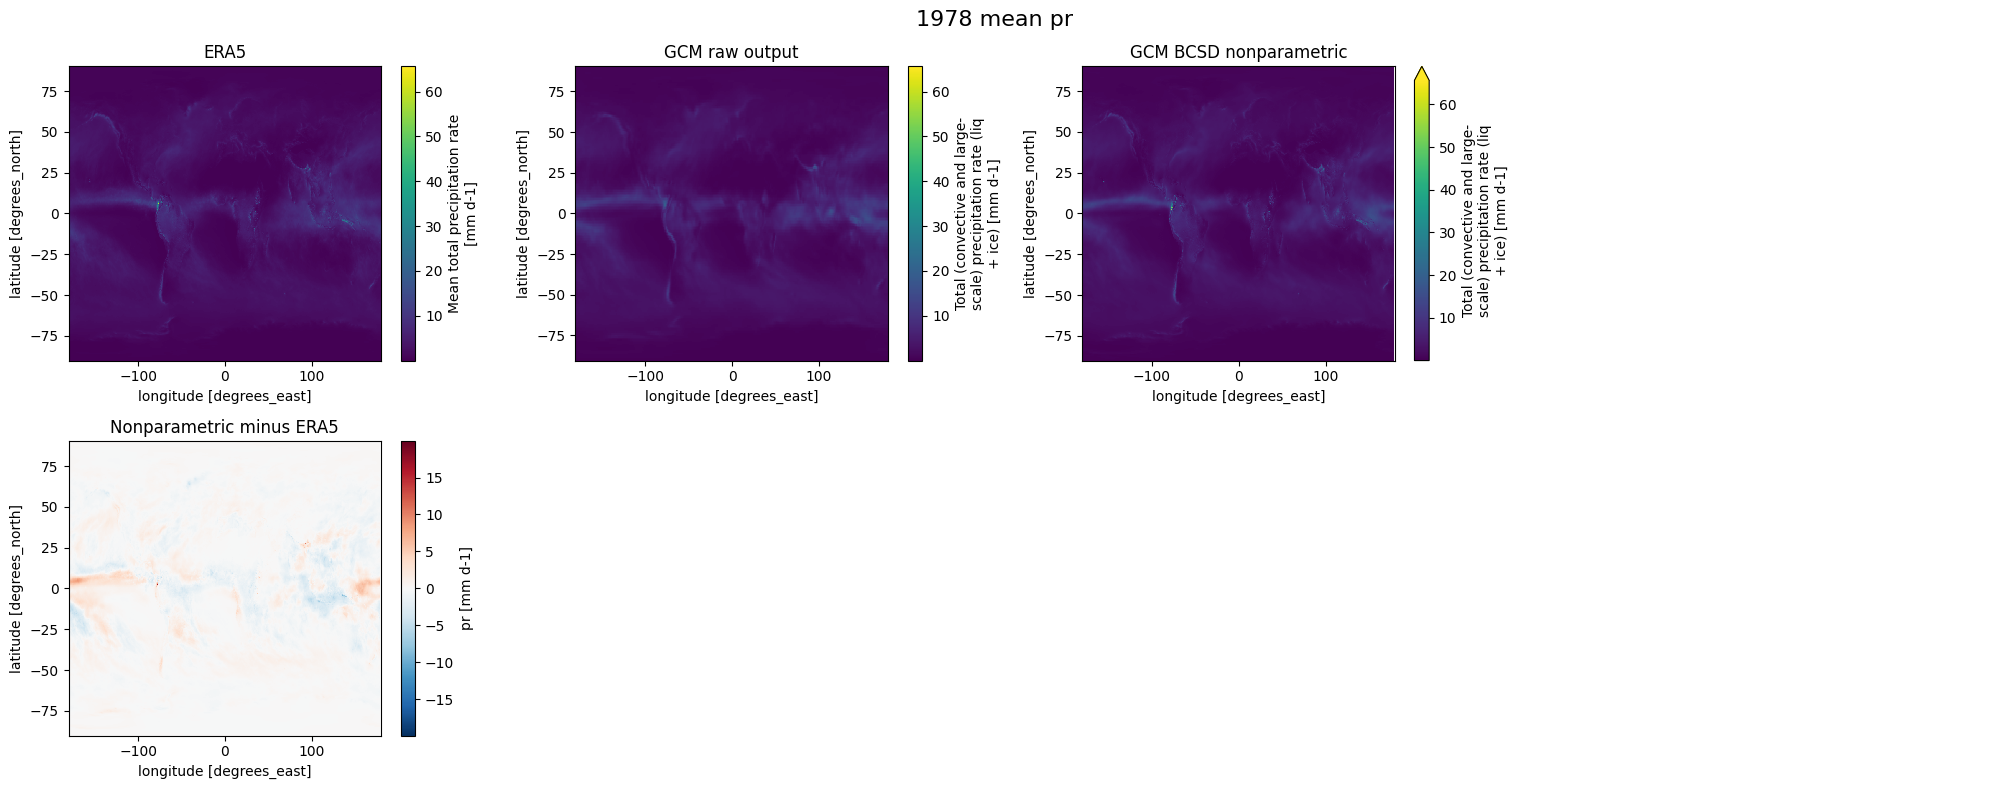

In [14]:
plot_comparisons(era5_pr_toplot, raw_pr_toplot, ds1_pr_toplot)

In [ ]:
raw_99p_toplot, era5_99p_toplot, ds1_99p_toplot, ds2_99p_toplot = calculate_statistic_to_plot(
    raw.isel(time=slice(0, 365)),
    era5.isel(time=slice(0, 365)),
    ds1.isel(time=slice(0, 365)),
    "99p",
    "pr"
)

In [ ]:
plot_comparisons(era5_99p_toplot, raw_99p_toplot, ds1_99p_toplot, ds2_99p_toplot)

In [ ]:
raw_dd_toplot, era5_dd_toplot, ds1_dd_toplot, ds2_dd_toplot = calculate_statistic_to_plot(
    raw.isel(time=slice(0, 365)),
    era5.isel(time=slice(0, 365)),
    ds1.isel(time=slice(0, 365)),
    "dry_days",
    "pr"
)

In [ ]:
plot_comparisons(era5_dd_toplot, raw_dd_toplot, ds1_dd_toplot)

In [ ]:
# Now plot temperature variables
ds1_tas = xr.open_dataset(
    "s3://carbonplan-srm/output/v0.3/CESM2-WACCM_tas_000_global_historical.zarr/")

In [ ]:
ds1_tas = ds1_tas.sel(time=training_period)

In [ ]:
raw_tas_toplot, era5_tas_toplot, ds1_tas_toplot, ds2_tas_toplot = calculate_statistic_to_plot(
    raw.isel(time=slice(0, 365)),
    era5.isel(time=slice(0, 365)),
    ds1_tas.isel(time=slice(0, 365)),
    "mean",
    "tas"
)

In [ ]:
plot_comparisons(era5_tas_toplot, raw_tas_toplot, ds1_tas_toplot, ds2_tas_toplot)

In [ ]:
raw_hot_day_toplot, era5_hot_day_toplot, ds1_hot_day_toplot, ds2_hot_day_toplot = (
    calculate_statistic_to_plot(
        raw.isel(time=slice(0, 365)),
        era5.isel(time=slice(0, 365)),
        ds1_tas.isel(time=slice(0, 365)),
        "hottest_day",
        "tas"
    )
)

In [ ]:
plot_comparisons(era5_hot_day_toplot, raw_hot_day_toplot, ds1_hot_day_toplot, ds2_hot_day_toplot)

In [ ]:
raw_gdd_toplot, era5_gdd_toplot, ds1_gdd_toplot, ds2_gdd_toplot = calculate_statistic_to_plot(
    raw.isel(time=slice(0, 365)),
    era5.isel(time=slice(0, 365)),
    ds1_tas.isel(time=slice(0, 365)),
    "gdd",
    "tas"
)

In [ ]:
plot_comparisons(era5_gdd_toplot, raw_gdd_toplot, ds1_gdd_toplot, ds2_gdd_toplot)

In [ ]:
raw_over30C_toplot, era5_over30C_toplot, ds1_over30C_toplot, ds2_over30C_toplot = (
    calculate_statistic_to_plot(
        raw.isel(time=slice(0, 365)),
        era5.isel(time=slice(0, 365)),
        ds1_tas.isel(time=slice(0, 365)),
        "days_over_30C",
        "tas"
    )
)

In [ ]:
plot_comparisons(era5_over30C_toplot, raw_over30C_toplot, ds1_over30C_toplot, ds2_over30C_toplot)

In [ ]:
locations = {
    "Cape Town": (-33.9221, 18.4231),
    "Addis Ababa": (9.0192, 38.7525),
    "Mumbai": (19.0728, 72.8826),
    "Sao Paulo": (-23.5558, -46.6396),
    "Berlin": (52.5200, 13.4050),
    "New York": (40.7128, -74.0060),
    "Sydney": (-33.8727, 151.2057),
    "Kyiv": (50.4504, 30.5245),
    "Beijing": (39.9042, 116.4074),
    "Accra": (5.5593, -0.1974),
    "Kualar Lumpur": (3.1319, 101.6841),
    "Lagos": (6.6137, 3.3553),
    "Rio de Janerio": (-22.9068, -43.1729),
    "Ankara": (39.9334, 32.8597),
    "Cairo": (30.0444, 31.2357),
    "Melbourne": (-37.8136, 144.9631),
    "Paris": (48.8575, 2.3514),
    "Tokyo": (35.6764, 139.6500),
    "Seoul": (37.5503, 126.9971),
    "Chicago": (41.8832, -87.6324),
    # TODO Temi: add in 9 more major cities around the world
    # TODO Temi: add in 10 locations from a variety of climatic zones around the world
}
Climatezones = {
    "Kualar Lumpur": (3.1319, 101.6841),
    "Lagos": (6.6137, 3.3553),
    "Rio de Janerio": (-22.9068, -43.1729),
    "Ankara": (39.9334, 32.8597),
    "Cairo": (30.0444, 31.2357),
    "Melbourne": (-37.8136, 144.9631),
    "Paris": (48.8575, 2.3514),
    "Tokyo": (35.6764, 139.6500),
    "Seoul": (37.5503, 126.9971),
    "Chicago": (41.8832, -87.6324),
}

In [48]:
# temi TODO: write a description here for why we're doing this kind of analysis

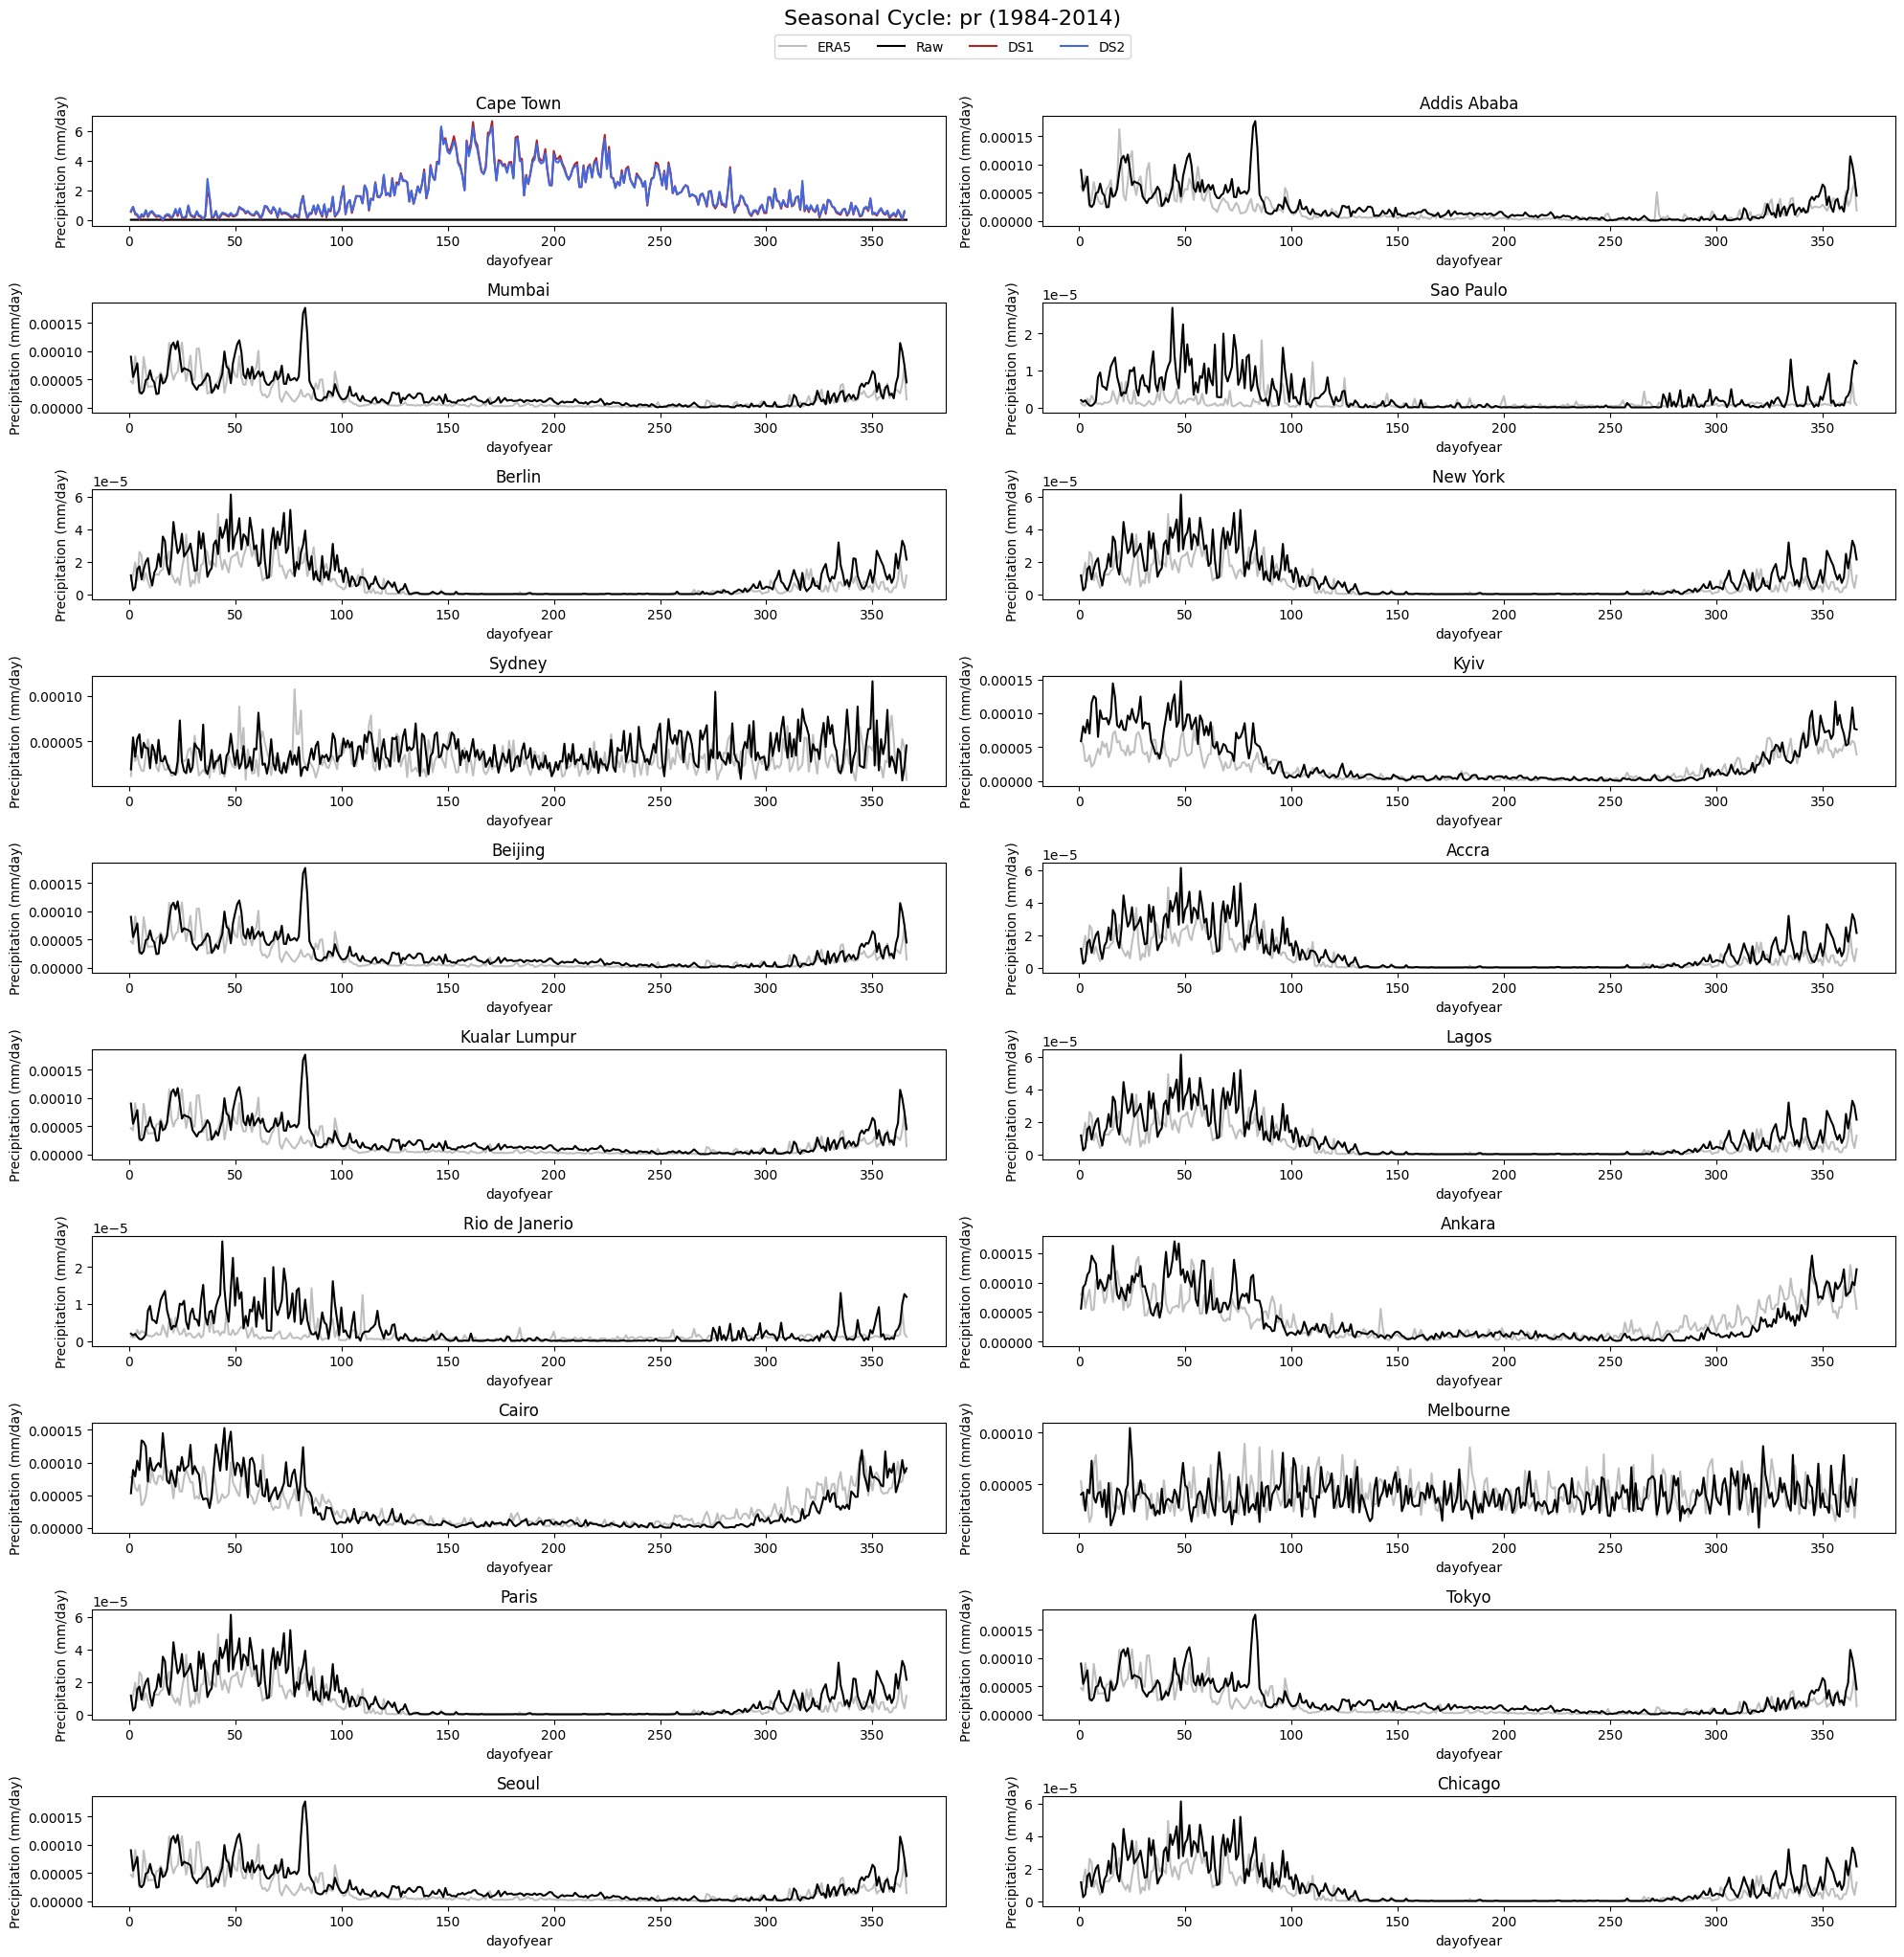

In [49]:
# temi TODO: add three more cells in this notebook, repeating these seasonal cycle plots for tasmax, tasmin, and tas
variable = "pr"
time_slice = slice("1984", "2014")

fig, axarr_shape = plt.subplots(nrows=10, ncols=2, figsize=(20, 20))
axarr = axarr_shape.flatten()
for i, (location, (lat, lon)) in enumerate(locations.items()):
    era5_toplot, raw_toplot, ds1_toplot, ds2_toplot = prep_datasets_for_seasonal_cycle_plotting(
        era5, raw, ds1, time_slice, lat, lon, variable, ds2=ds2
    )

    plot_timeseries(axarr[i], era5_toplot, raw_toplot, ds1_toplot, location, ds2_toplot)
    axarr[i].set_title(location)
    axarr[i].set_ylabel("Precipitation (mm/day)")

fig.suptitle(
    f"Seasonal Cycle: {variable} ({time_slice.start}-{time_slice.stop})", fontsize=16, y=1.02
)
fig.legend(["ERA5", "Raw", "DS1", "DS2"], loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
# temi TODO: add a single legend applying to all of the panels of plots, above the figure
# temi TODO: add a title at the top of this figure (as part of the function) describing the variable and time period
# temi TODO: fix ylabels to have units

In [50]:
print("ERA5 extent:")
print(f"  Lat: {float(era5.lat.min())} to {float(era5.lat.max())}")
print(f"  Lon: {float(era5.lon.min())} to {float(era5.lon.max())}")

print("\nRaw extent:")
print(f"  Lat: {float(raw.lat.min())} to {float(raw.lat.max())}")
print(f"  Lon: {float(raw.lon.min())} to {float(raw.lon.max())}")

print("\nDS1 extent:")
print(f"  Lat: {float(ds1.lat.min())} to {float(ds1.lat.max())}")
print(f"  Lon: {float(ds1.lon.min())} to {float(ds1.lon.max())}")

ERA5 extent:
  Lat: -48.75 to -20.25
  Lon: 14.5 to 39.75

Raw extent:
  Lat: -48.53403141361257 to -20.261780104712045
  Lon: 15.0 to 38.75

DS1 extent:
  Lat: -48.75 to -20.25
  Lon: 14.5 to 39.75


In [51]:
# Make a figure with all of the timeseries for all of the locations for the same time slice
# Repeat for a randomly selected year - for ease of calendar use only choose non-leap year calendars

In [52]:
ds_list = [era5, raw, ds1, ds2]

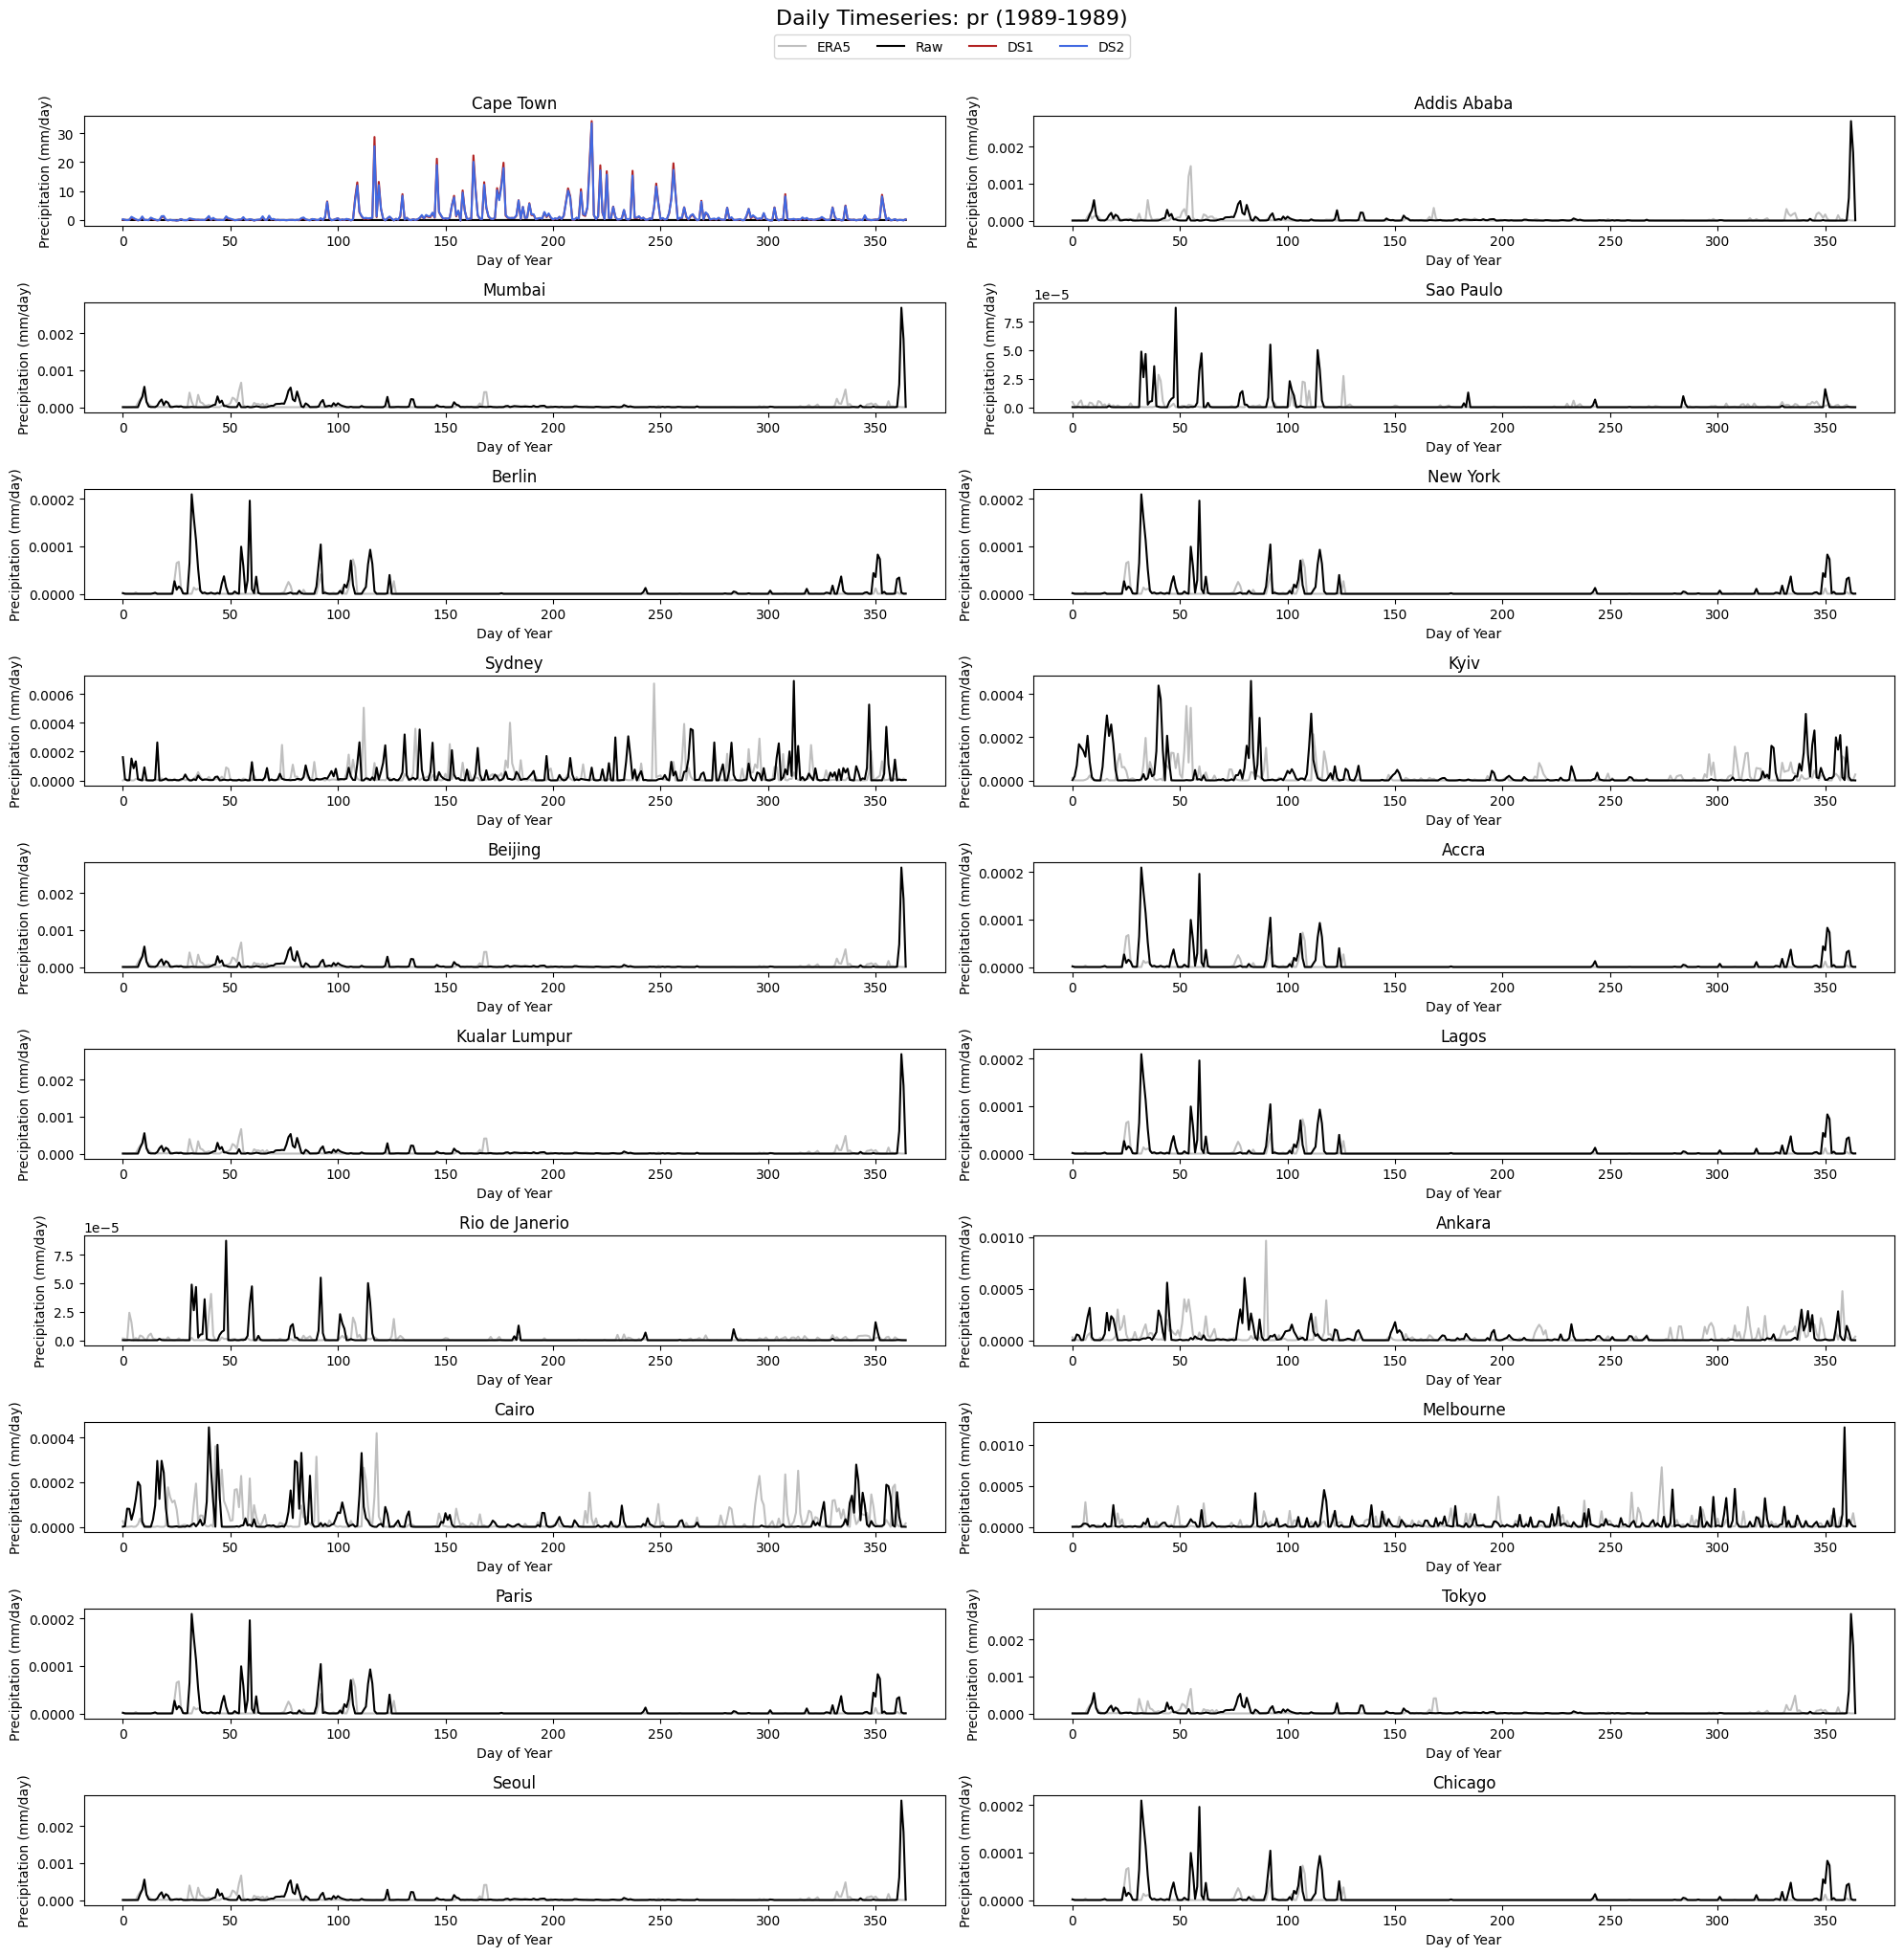

In [53]:
variable = "pr"
time_slice = slice("1989", "1989")

fig, axarr_shape = plt.subplots(nrows=10, ncols=2, figsize=(20, 20))
axarr = axarr_shape.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    # First select time, THEN select point with method='nearest'
    era5_sub = era5.sel(time=time_slice).sel(lat=lat, lon=lon, method="nearest")
    raw_sub = raw.sel(time=time_slice).sel(lat=lat, lon=lon, method="nearest")
    ds1_sub = ds1.sel(time=time_slice).sel(lat=lat, lon=lon, method="nearest")
    ds2_sub = ds2.sel(time=time_slice).sel(lat=lat, lon=lon, method="nearest")

    # Plot using .values to avoid datetime issues
    axarr[i].plot(era5_sub[variable].values, color="grey", alpha=0.5)
    axarr[i].plot(raw_sub[variable].values, color="k")
    axarr[i].plot(ds1_sub[variable].values, color="firebrick")
    axarr[i].plot(ds2_sub[variable].values, color="royalblue")

    axarr[i].set_title(location)
    axarr[i].set_ylabel("Precipitation (mm/day)")
    axarr[i].set_xlabel("Day of Year")

fig.suptitle(
    f"Daily Timeseries: {variable} ({time_slice.start}-{time_slice.stop})", fontsize=16, y=1.02
)
fig.legend(["ERA5", "Raw", "DS1", "DS2"], loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

In [54]:
# era5_toplot = sel_point(era5, lat, lon)[variable]
# raw_toplot = sel_point(raw, lat, lon)[variable]
# ds1_toplot = sel_point(ds1, lat, lon)[variable]
# ds2_toplot = sel_point(ds2, lat, lon)[variable]
# selected_location = 'Cape Town'
# lat, lon = locations[selected_location]

# era5_toplot = era5.sel(lat=lat, lon=lon, method='nearest')[variable]
# raw_toplot = raw.sel(lat=lat, lon=lon, method='nearest')[variable]
# ds1_toplot = ds1.sel(lat=lat, lon=lon, method='nearest')[variable]
# ds2_toplot = ds2.sel(lat=lat, lon=lon, method='nearest')[variable]

# print(f"Selected location: {selected_location} (lat={lat}, lon={lon})")

selected_location = "Cape Town"
lat, lon = locations[selected_location]

era5_toplot = era5.sel(lat=lat, lon=lon, method="nearest")[variable].compute()
raw_toplot = raw.sel(lat=lat, lon=lon, method="nearest")[variable].compute()
ds1_toplot = ds1.sel(lat=lat, lon=lon, method="nearest")[variable].compute()
ds2_toplot = ds2.sel(lat=lat, lon=lon, method="nearest")[variable].compute()

# Filter to wet days only (> 0.1 mm/day) for better visualization
threshold = 0.01
era5_toplot = era5_toplot.where(era5_toplot > threshold, drop=True)
raw_toplot = raw_toplot.where(raw_toplot > threshold, drop=True)
ds1_toplot = ds1_toplot.where(ds1_toplot > threshold, drop=True)
ds2_toplot = ds2_toplot.where(ds2_toplot > threshold, drop=True)

print(f"Selected location: {selected_location} (lat={lat}, lon={lon})")
print(f"Filtered to wet days (>{threshold} mm/day)")

Selected location: Cape Town (lat=-33.9221, lon=18.4231)
Filtered to wet days (>0.01 mm/day)


In [55]:
era5_global = catalog.get("ERA5").to_xarray()
era5_global = era5_global.sel(time=training_period)
era5_global["pr"] = convert_precip_units(era5_global["pr"])

raw_global = catalog.get(dataset_name).to_xarray()
raw_global = raw_global.sel(time=training_period)
raw_global["pr"] = convert_precip_units(raw_global["pr"])

print("Loaded global ERA5 and raw for PDF/CDF analysis")
print("Converted precipitation to mm/day")
print(f"ERA5 pr max: {float(era5_global['pr'].max()):.2f} {era5_global.pr.units}")
print(f"Raw pr max: {float(raw_global['pr'].max()):.2f} {raw_global.pr.units}")

Loaded global ERA5 and raw for PDF/CDF analysis
Converted precipitation to mm/day
ERA5 pr max: 757.07 mm d-1
Raw pr max: 469.04 mm d-1


In [56]:
def extract_location_data(
    era5, raw, ds1, ds2, lat, lon, variable, filter_precip=True, threshold=0.1
):
    """
    Extract data for a location. Returns None for datasets without coverage.
    For precipitation, optionally filters to wet days only.
    """
    result = {}

    # ERA5
    try:
        data = era5.sel(lat=lat, lon=lon, method="nearest")[variable].compute()
        if filter_precip and variable == "pr":
            data = data.where(data > threshold, drop=True)
        result["era5"] = data
    except Exception as e:
        print(f"ERA5 error for {lat}, {lon}: {e}")
        result["era5"] = None

    # Raw GCM
    try:
        data = raw.sel(lat=lat, lon=lon, method="nearest")[variable].compute()
        if filter_precip and variable == "pr":
            data = data.where(data > threshold, drop=True)
        result["raw"] = data
    except Exception as e:
        print(f"Raw error for {lat}, {lon}: {e}")
        result["raw"] = None

    # DS1
    try:
        data = ds1.sel(lat=lat, lon=lon, method="nearest")[variable].compute()
        if filter_precip and variable == "pr":
            data = data.where(data > threshold, drop=True)
        result["ds1"] = data
    except Exception:
        result["ds1"] = None

    # DS2
    try:
        data = ds2.sel(lat=lat, lon=lon, method="nearest")[variable].compute()
        if filter_precip and variable == "pr":
            data = data.where(data > threshold, drop=True)
        result["ds2"] = data
    except Exception:
        result["ds2"] = None

    return result


print("extract_location_data function defined")

extract_location_data function defined


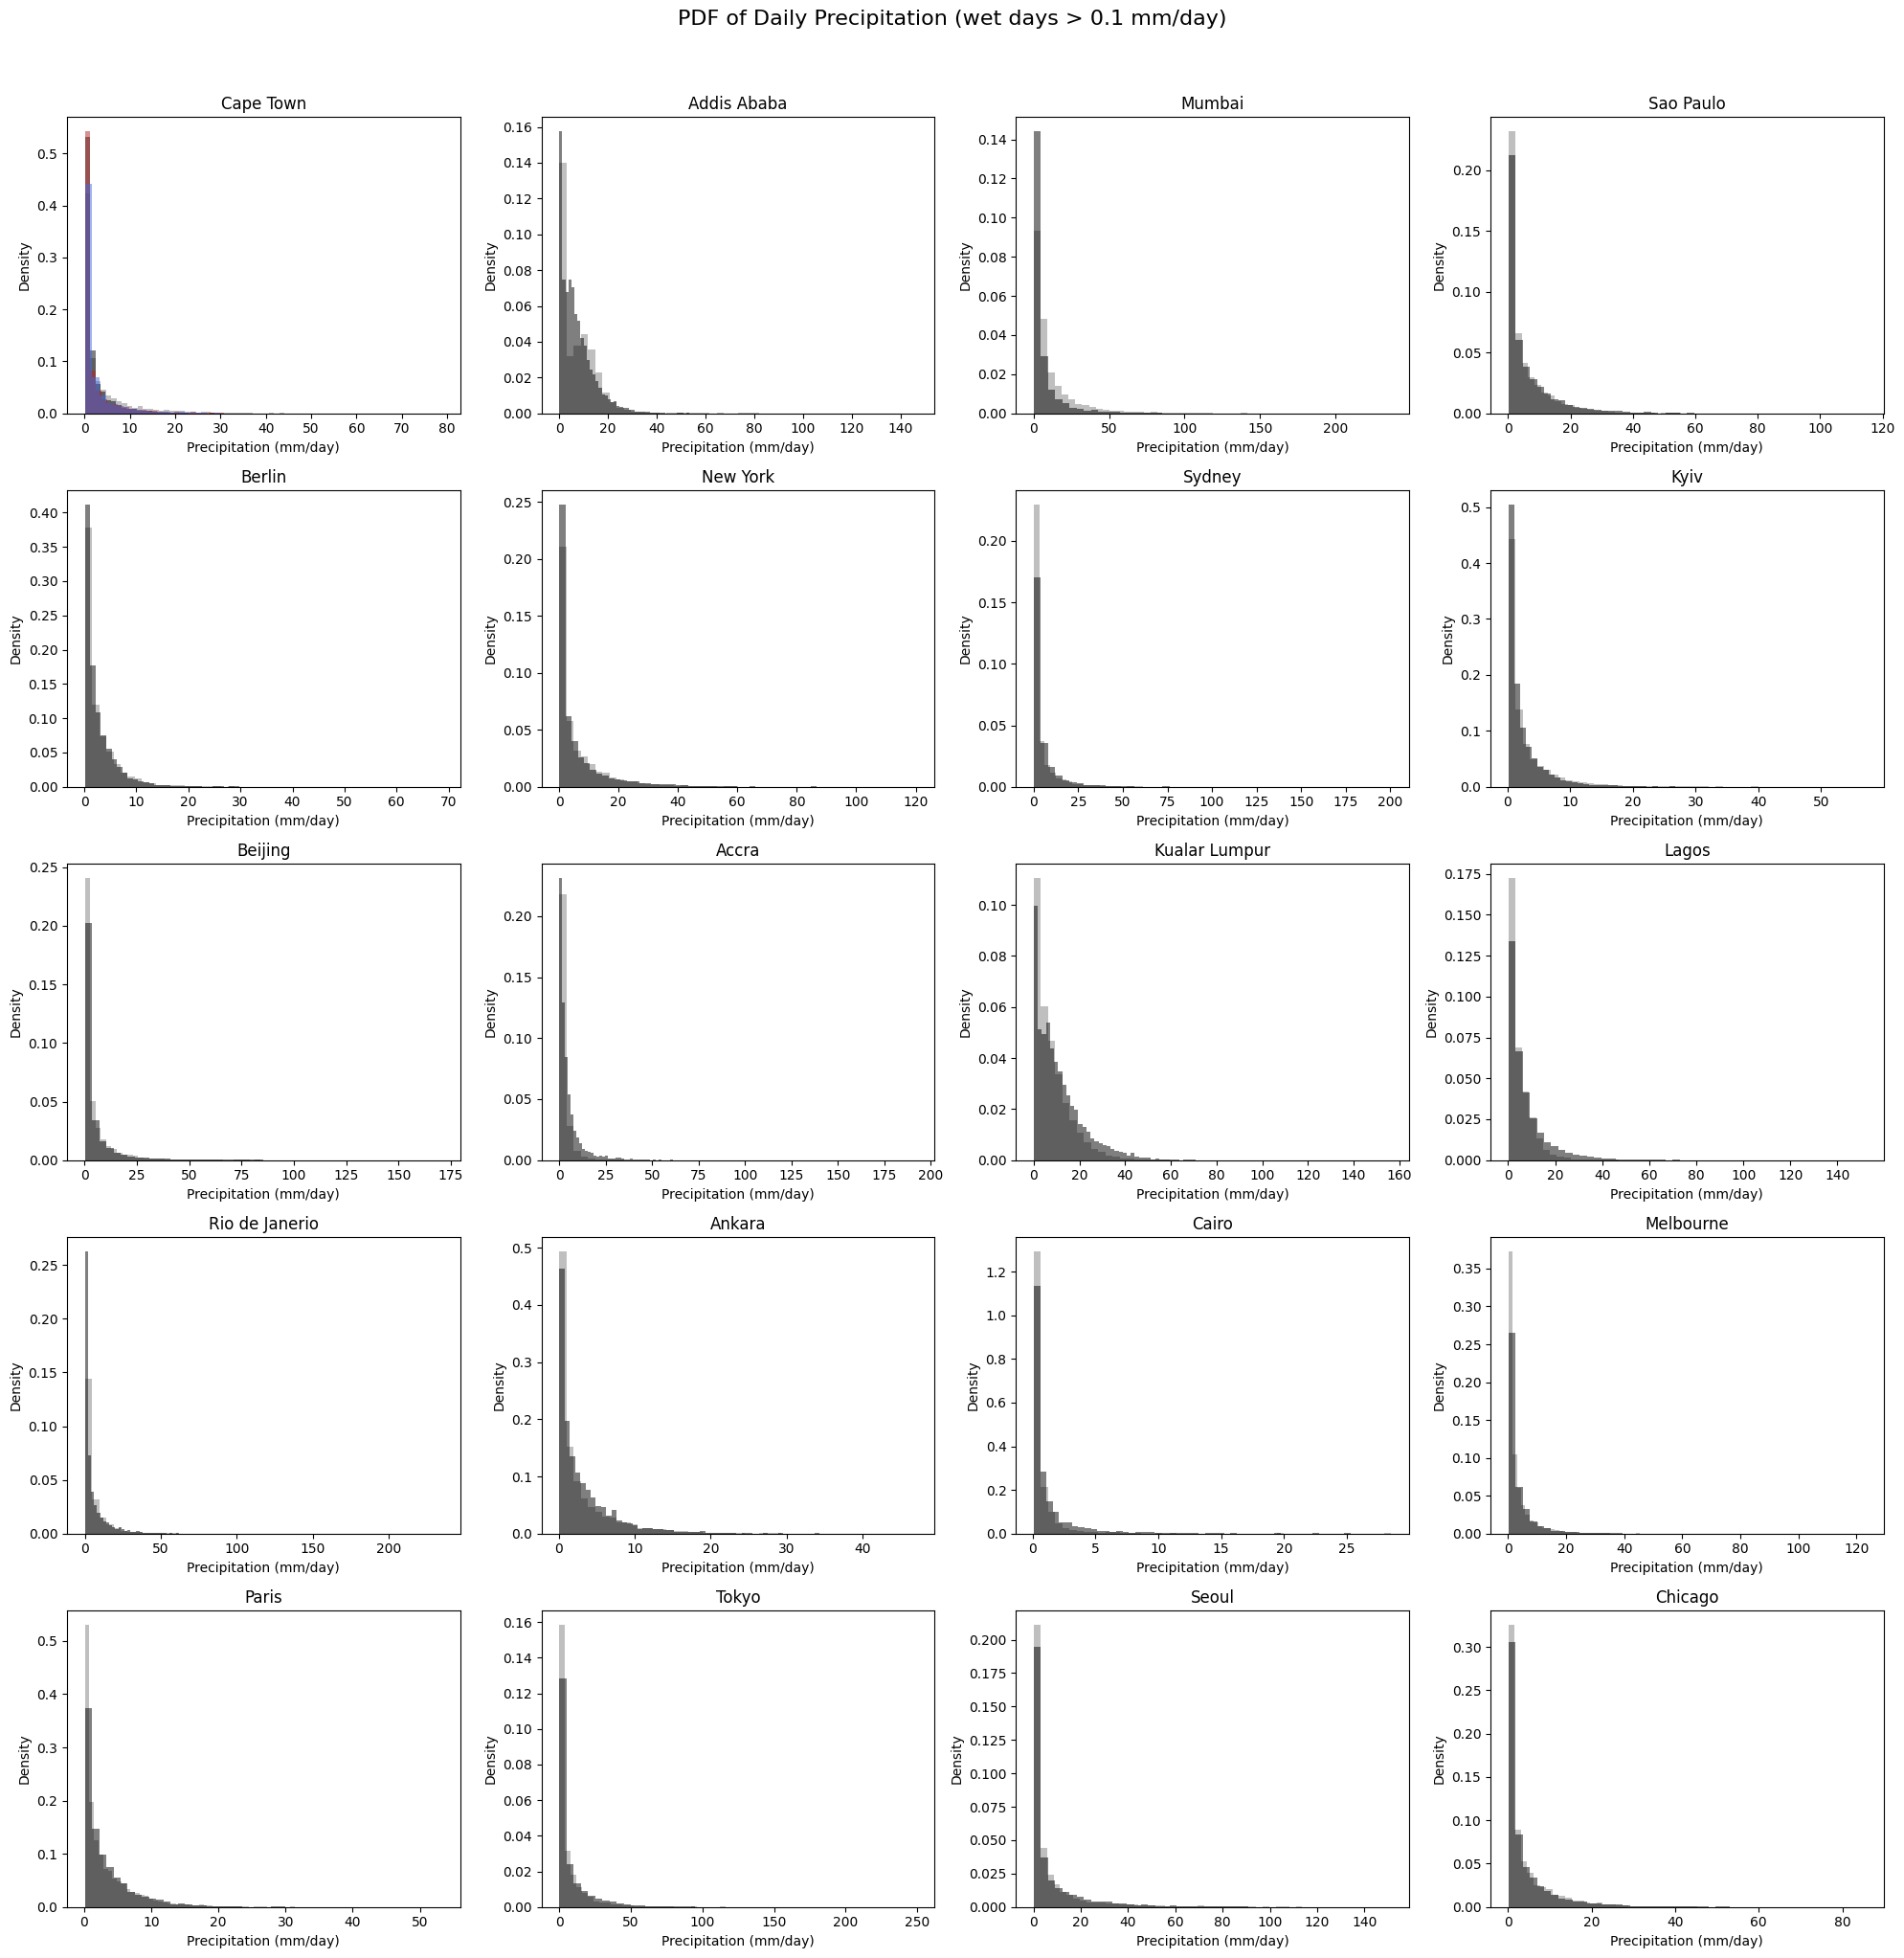

In [57]:
# PDF - Precipitation (all locations)
variable = "pr"
threshold = 0.1

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]

    try:
        data = extract_location_data(
            era5_global,
            raw_global,
            ds1,
            ds2,
            lat,
            lon,
            variable,
            filter_precip=True,
            threshold=threshold,
        )

        has_data = False
        if data["era5"] is not None and len(data["era5"]) > 0:
            ax.hist(
                data["era5"].values, bins=50, alpha=0.5, color="grey", density=True, label="ERA5"
            )
            has_data = True
        if data["raw"] is not None and len(data["raw"]) > 0:
            ax.hist(data["raw"].values, bins=50, alpha=0.5, color="k", density=True, label="Raw")
            has_data = True
        if data["ds1"] is not None and len(data["ds1"]) > 0:
            ax.hist(
                data["ds1"].values, bins=50, alpha=0.5, color="firebrick", density=True, label="DS1"
            )
            has_data = True
        if data["ds2"] is not None and len(data["ds2"]) > 0:
            ax.hist(
                data["ds2"].values, bins=50, alpha=0.5, color="royalblue", density=True, label="DS2"
            )
            has_data = True

        if not has_data:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(location)
        ax.set_xlabel("Precipitation (mm/day)")
        ax.set_ylabel("Density")

    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {str(e)[:20]}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle(f"PDF of Daily Precipitation (wet days > {threshold} mm/day)", fontsize=16, y=1.02)
# fig.legend(['ERA5', 'Raw', 'DS1', 'DS2'], loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

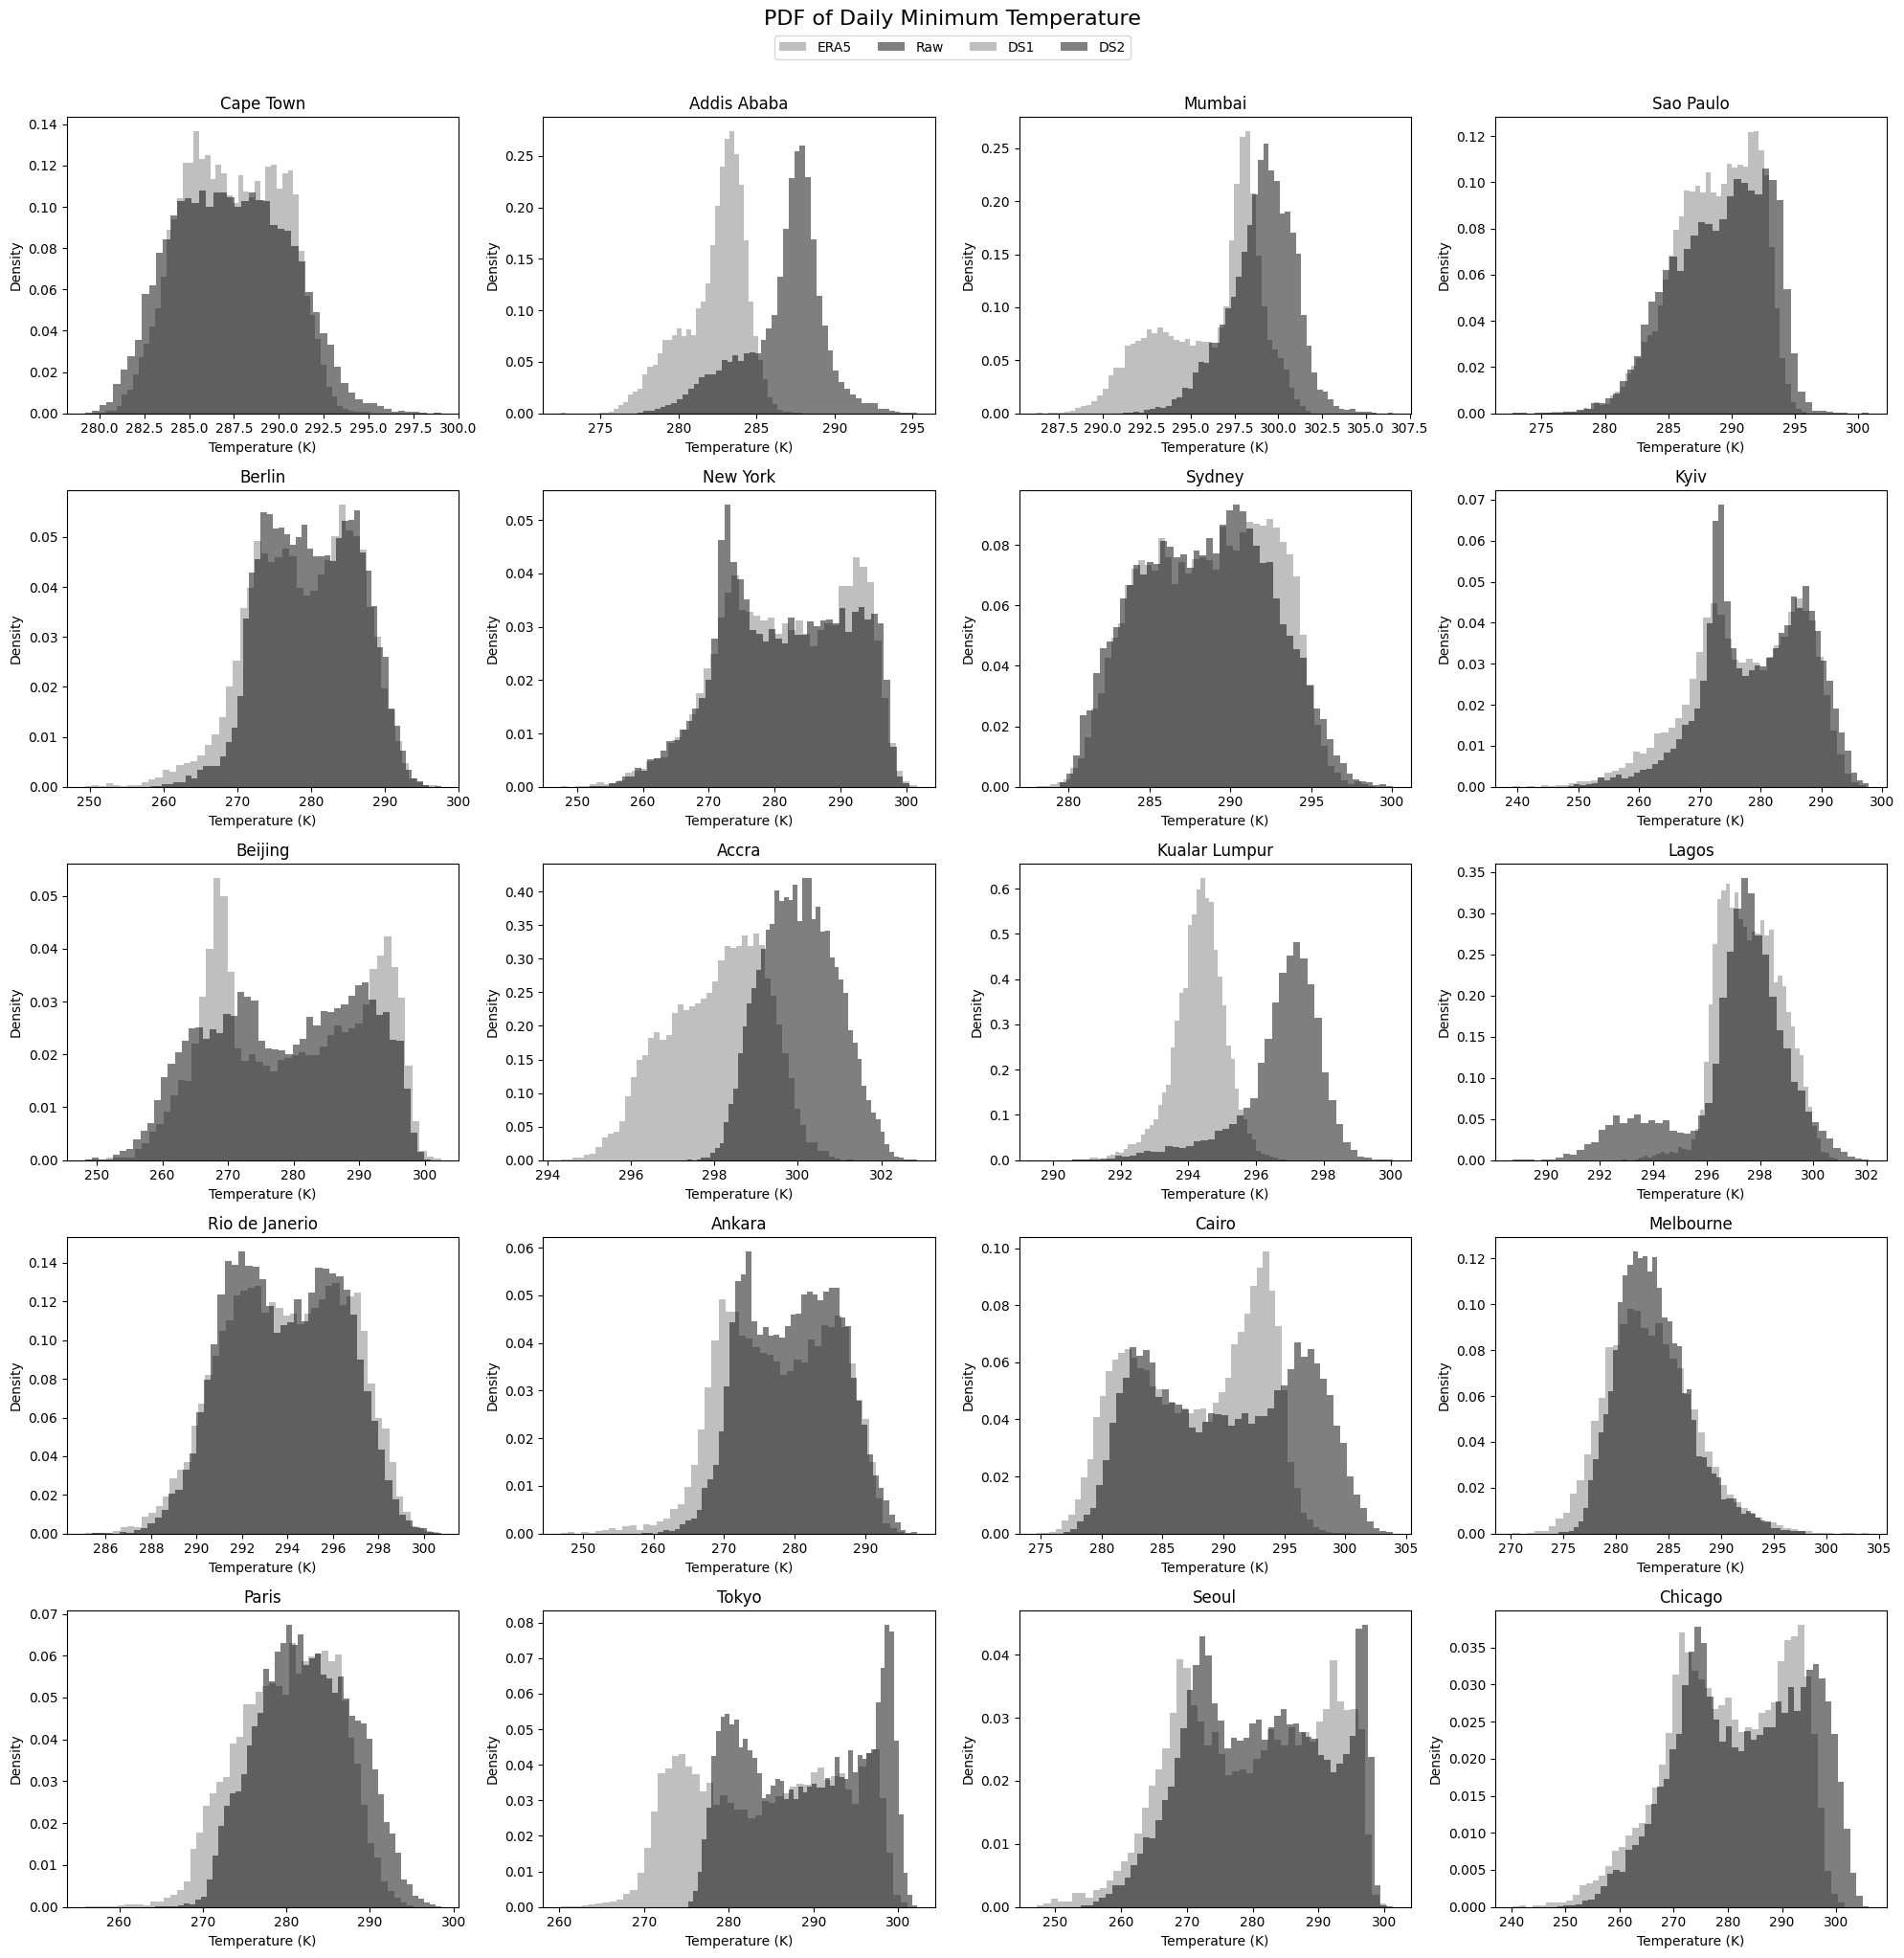

In [58]:
variable = "tasmin"

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]

    try:
        data = extract_location_data(
            era5_global, raw_global, ds1_tas, ds2_tas, lat, lon, variable, filter_precip=False
        )

        has_data = False
        if data["era5"] is not None and len(data["era5"]) > 0:
            ax.hist(
                data["era5"].values, bins=50, alpha=0.5, color="grey", density=True, label="ERA5"
            )
            has_data = True
        if data["raw"] is not None and len(data["raw"]) > 0:
            ax.hist(data["raw"].values, bins=50, alpha=0.5, color="k", density=True, label="Raw")
            has_data = True
        if data["ds1"] is not None and len(data["ds1"]) > 0:
            ax.hist(
                data["ds1"].values, bins=50, alpha=0.5, color="firebrick", density=True, label="DS1"
            )
            has_data = True
        if data["ds2"] is not None and len(data["ds2"]) > 0:
            ax.hist(
                data["ds2"].values, bins=50, alpha=0.5, color="royalblue", density=True, label="DS2"
            )
            has_data = True

        if not has_data:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(location)
        ax.set_xlabel("Temperature (K)")
        ax.set_ylabel("Density")

    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {str(e)[:20]}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle("PDF of Daily Minimum Temperature", fontsize=16, y=1.02)
fig.legend(["ERA5", "Raw", "DS1", "DS2"], loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

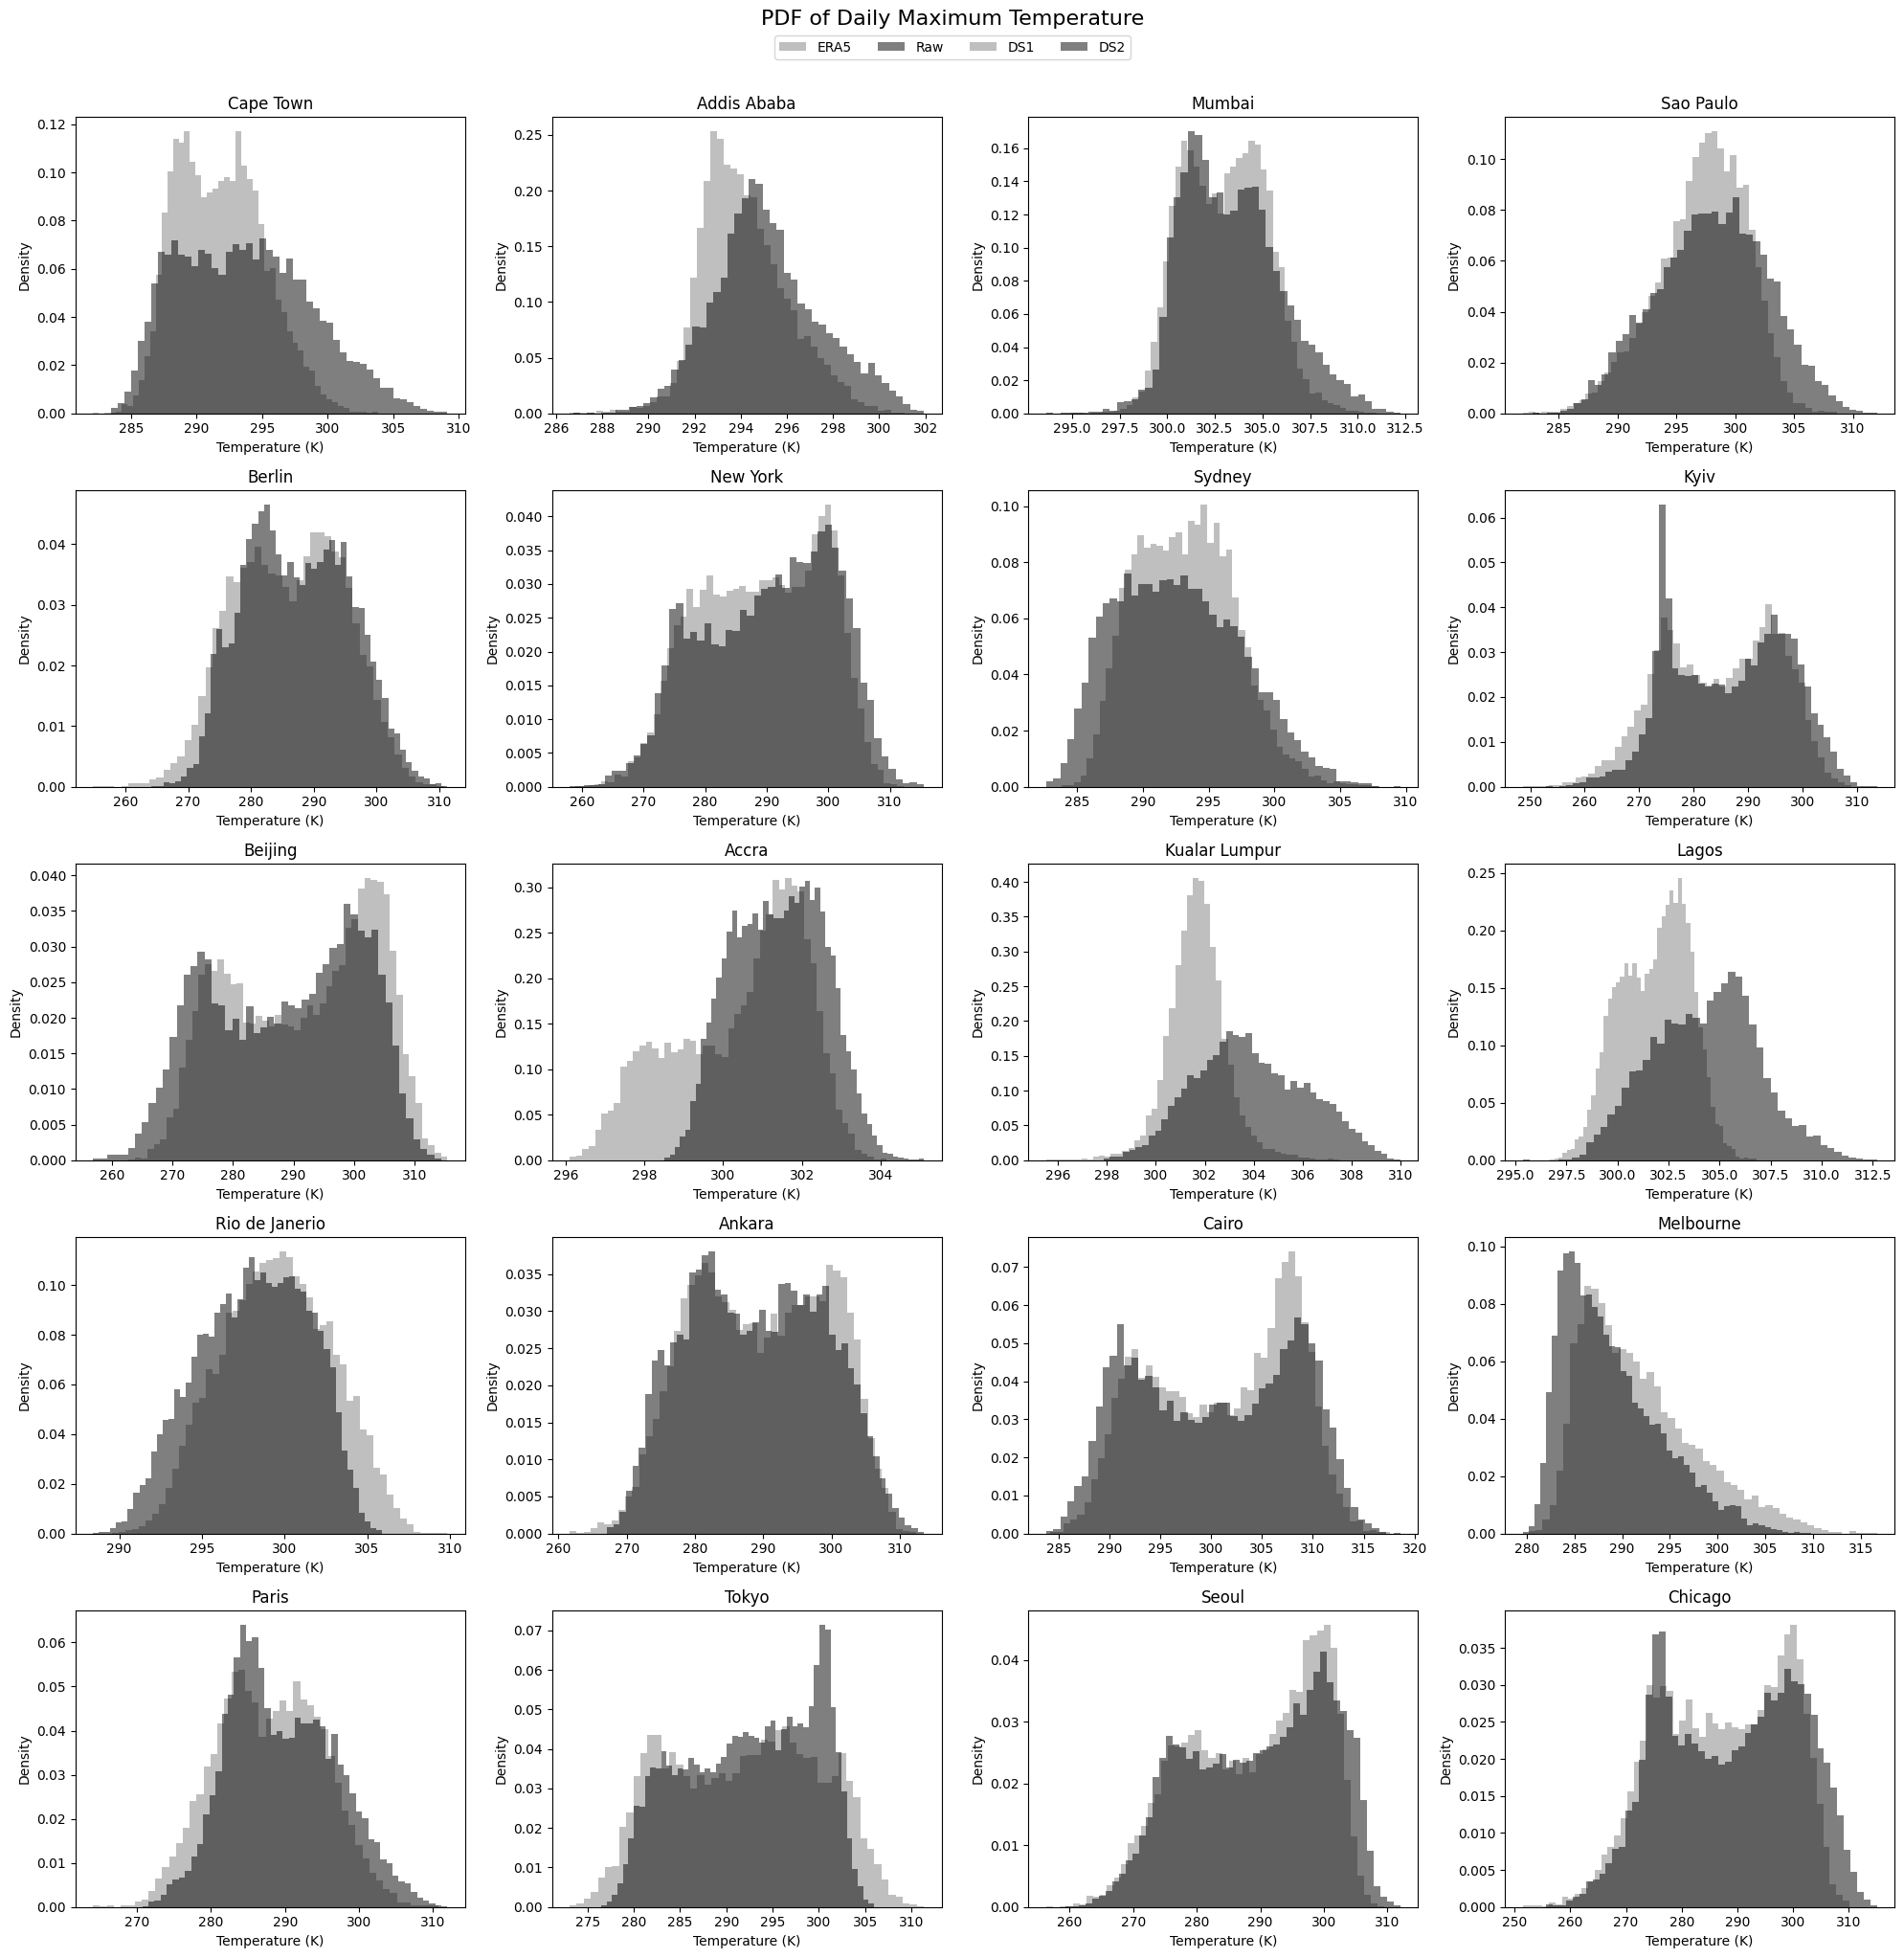

In [59]:
variable = "tasmax"

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]

    try:
        data = extract_location_data(
            era5_global, raw_global, ds1_tas, ds2_tas, lat, lon, variable, filter_precip=False
        )

        has_data = False
        if data["era5"] is not None and len(data["era5"]) > 0:
            ax.hist(
                data["era5"].values, bins=50, alpha=0.5, color="grey", density=True, label="ERA5"
            )
            has_data = True
        if data["raw"] is not None and len(data["raw"]) > 0:
            ax.hist(
                data["raw"].values, bins=50, alpha=0.5, color="black", density=True, label="Raw"
            )
            has_data = True
        if data["ds1"] is not None and len(data["ds1"]) > 0:
            ax.hist(data["ds1"].values, bins=50, alpha=0.5, color="red", density=True, label="DS1")
            has_data = True
        if data["ds2"] is not None and len(data["ds2"]) > 0:
            ax.hist(data["ds2"].values, bins=50, alpha=0.5, color="blue", density=True, label="DS2")
            has_data = True

        if not has_data:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(location)
        ax.set_xlabel("Temperature (K)")
        ax.set_ylabel("Density")

    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {str(e)[:20]}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle("PDF of Daily Maximum Temperature", fontsize=16, y=1.02)
fig.legend(["ERA5", "Raw", "DS1", "DS2"], loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

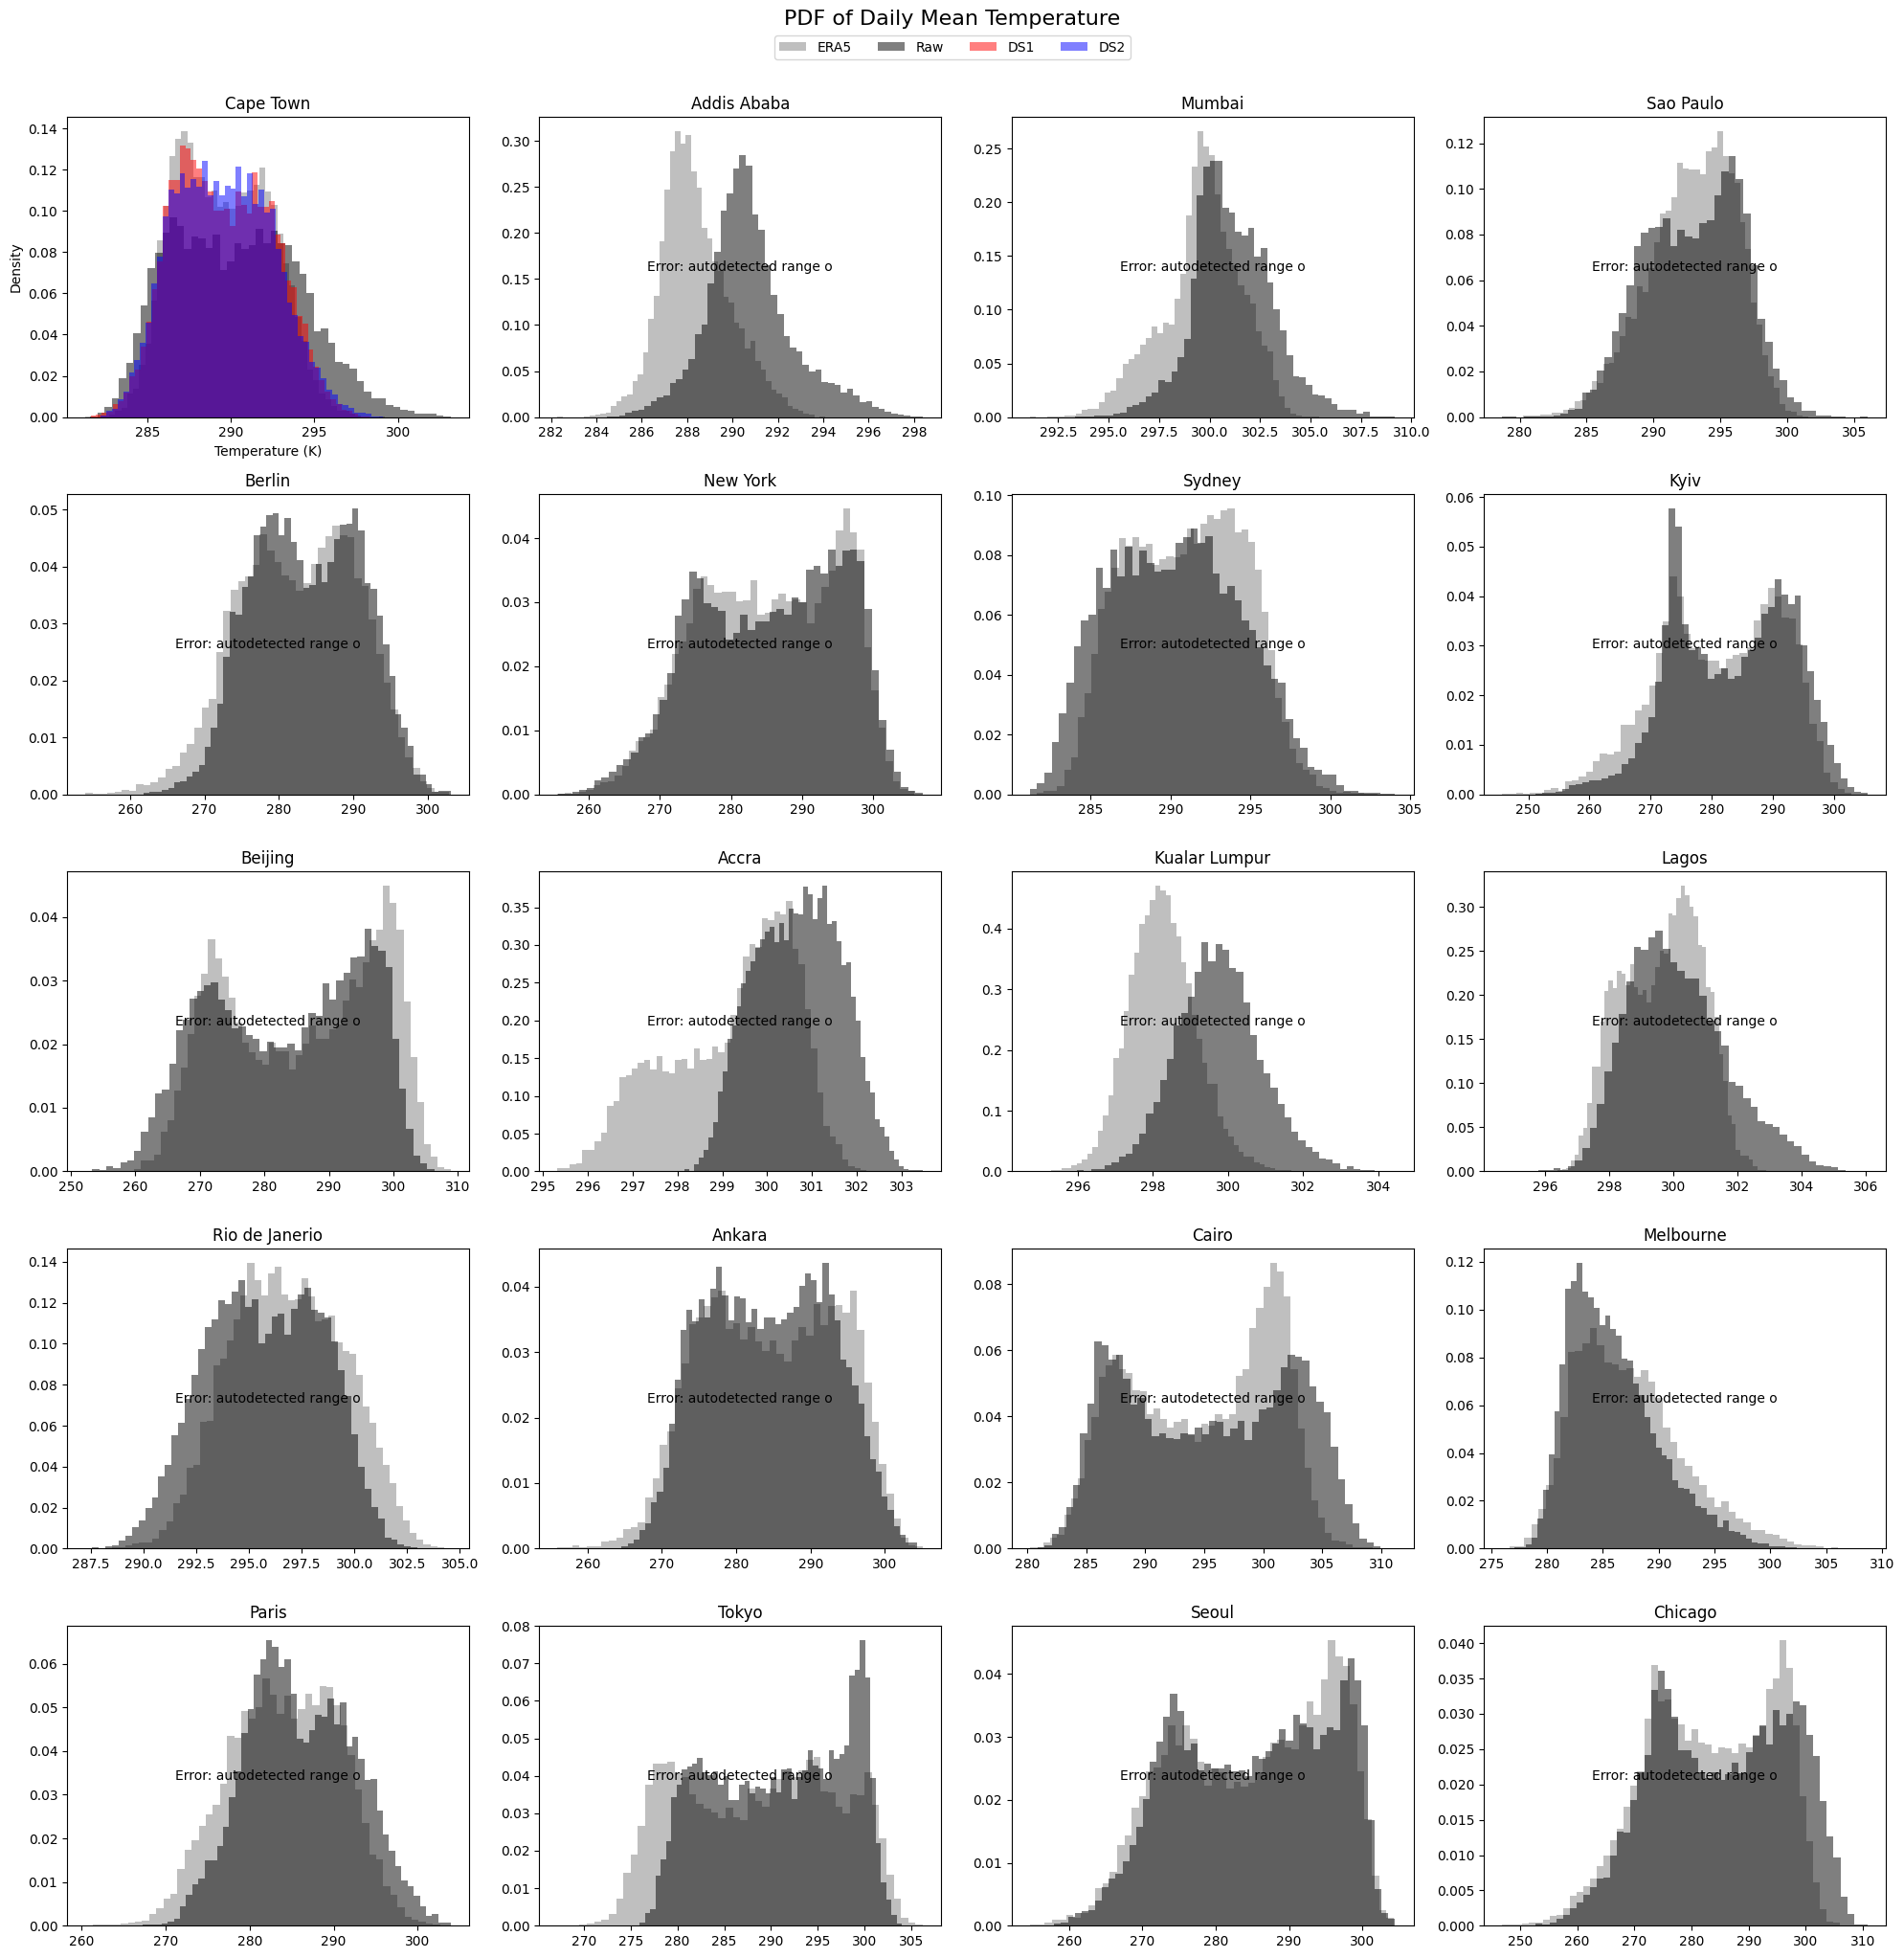

In [60]:
variable = "tas"

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]

    try:
        data = extract_location_data(
            era5_global, raw_global, ds1_tas, ds2_tas, lat, lon, variable, filter_precip=False
        )

        has_data = False
        if data["era5"] is not None and len(data["era5"]) > 0:
            ax.hist(
                data["era5"].values, bins=50, alpha=0.5, color="grey", density=True, label="ERA5"
            )
            has_data = True
        if data["raw"] is not None and len(data["raw"]) > 0:
            ax.hist(
                data["raw"].values, bins=50, alpha=0.5, color="black", density=True, label="Raw"
            )
            has_data = True
        if data["ds1"] is not None and len(data["ds1"]) > 0:
            ax.hist(data["ds1"].values, bins=50, alpha=0.5, color="red", density=True, label="DS1")
            has_data = True
        if data["ds2"] is not None and len(data["ds2"]) > 0:
            ax.hist(data["ds2"].values, bins=50, alpha=0.5, color="blue", density=True, label="DS2")
            has_data = True

        if not has_data:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(location)
        ax.set_xlabel("Temperature (K)")
        ax.set_ylabel("Density")

    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {str(e)[:20]}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle("PDF of Daily Mean Temperature", fontsize=16, y=1.02)
fig.legend(["ERA5", "Raw", "DS1", "DS2"], loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

In [61]:
# A PDF shows how often different rainfall amounts occur, helping to see typical values and variability. A CDF shows the fraction of days with rainfall below a given amount, making it easier to understand how often heavy or extreme rainfall events occur. These plots show that raw GCM output tends to underestimate extreme rainfall events while overestimating the frequency of low rainfall days, a common bias known as the drizzle bias.

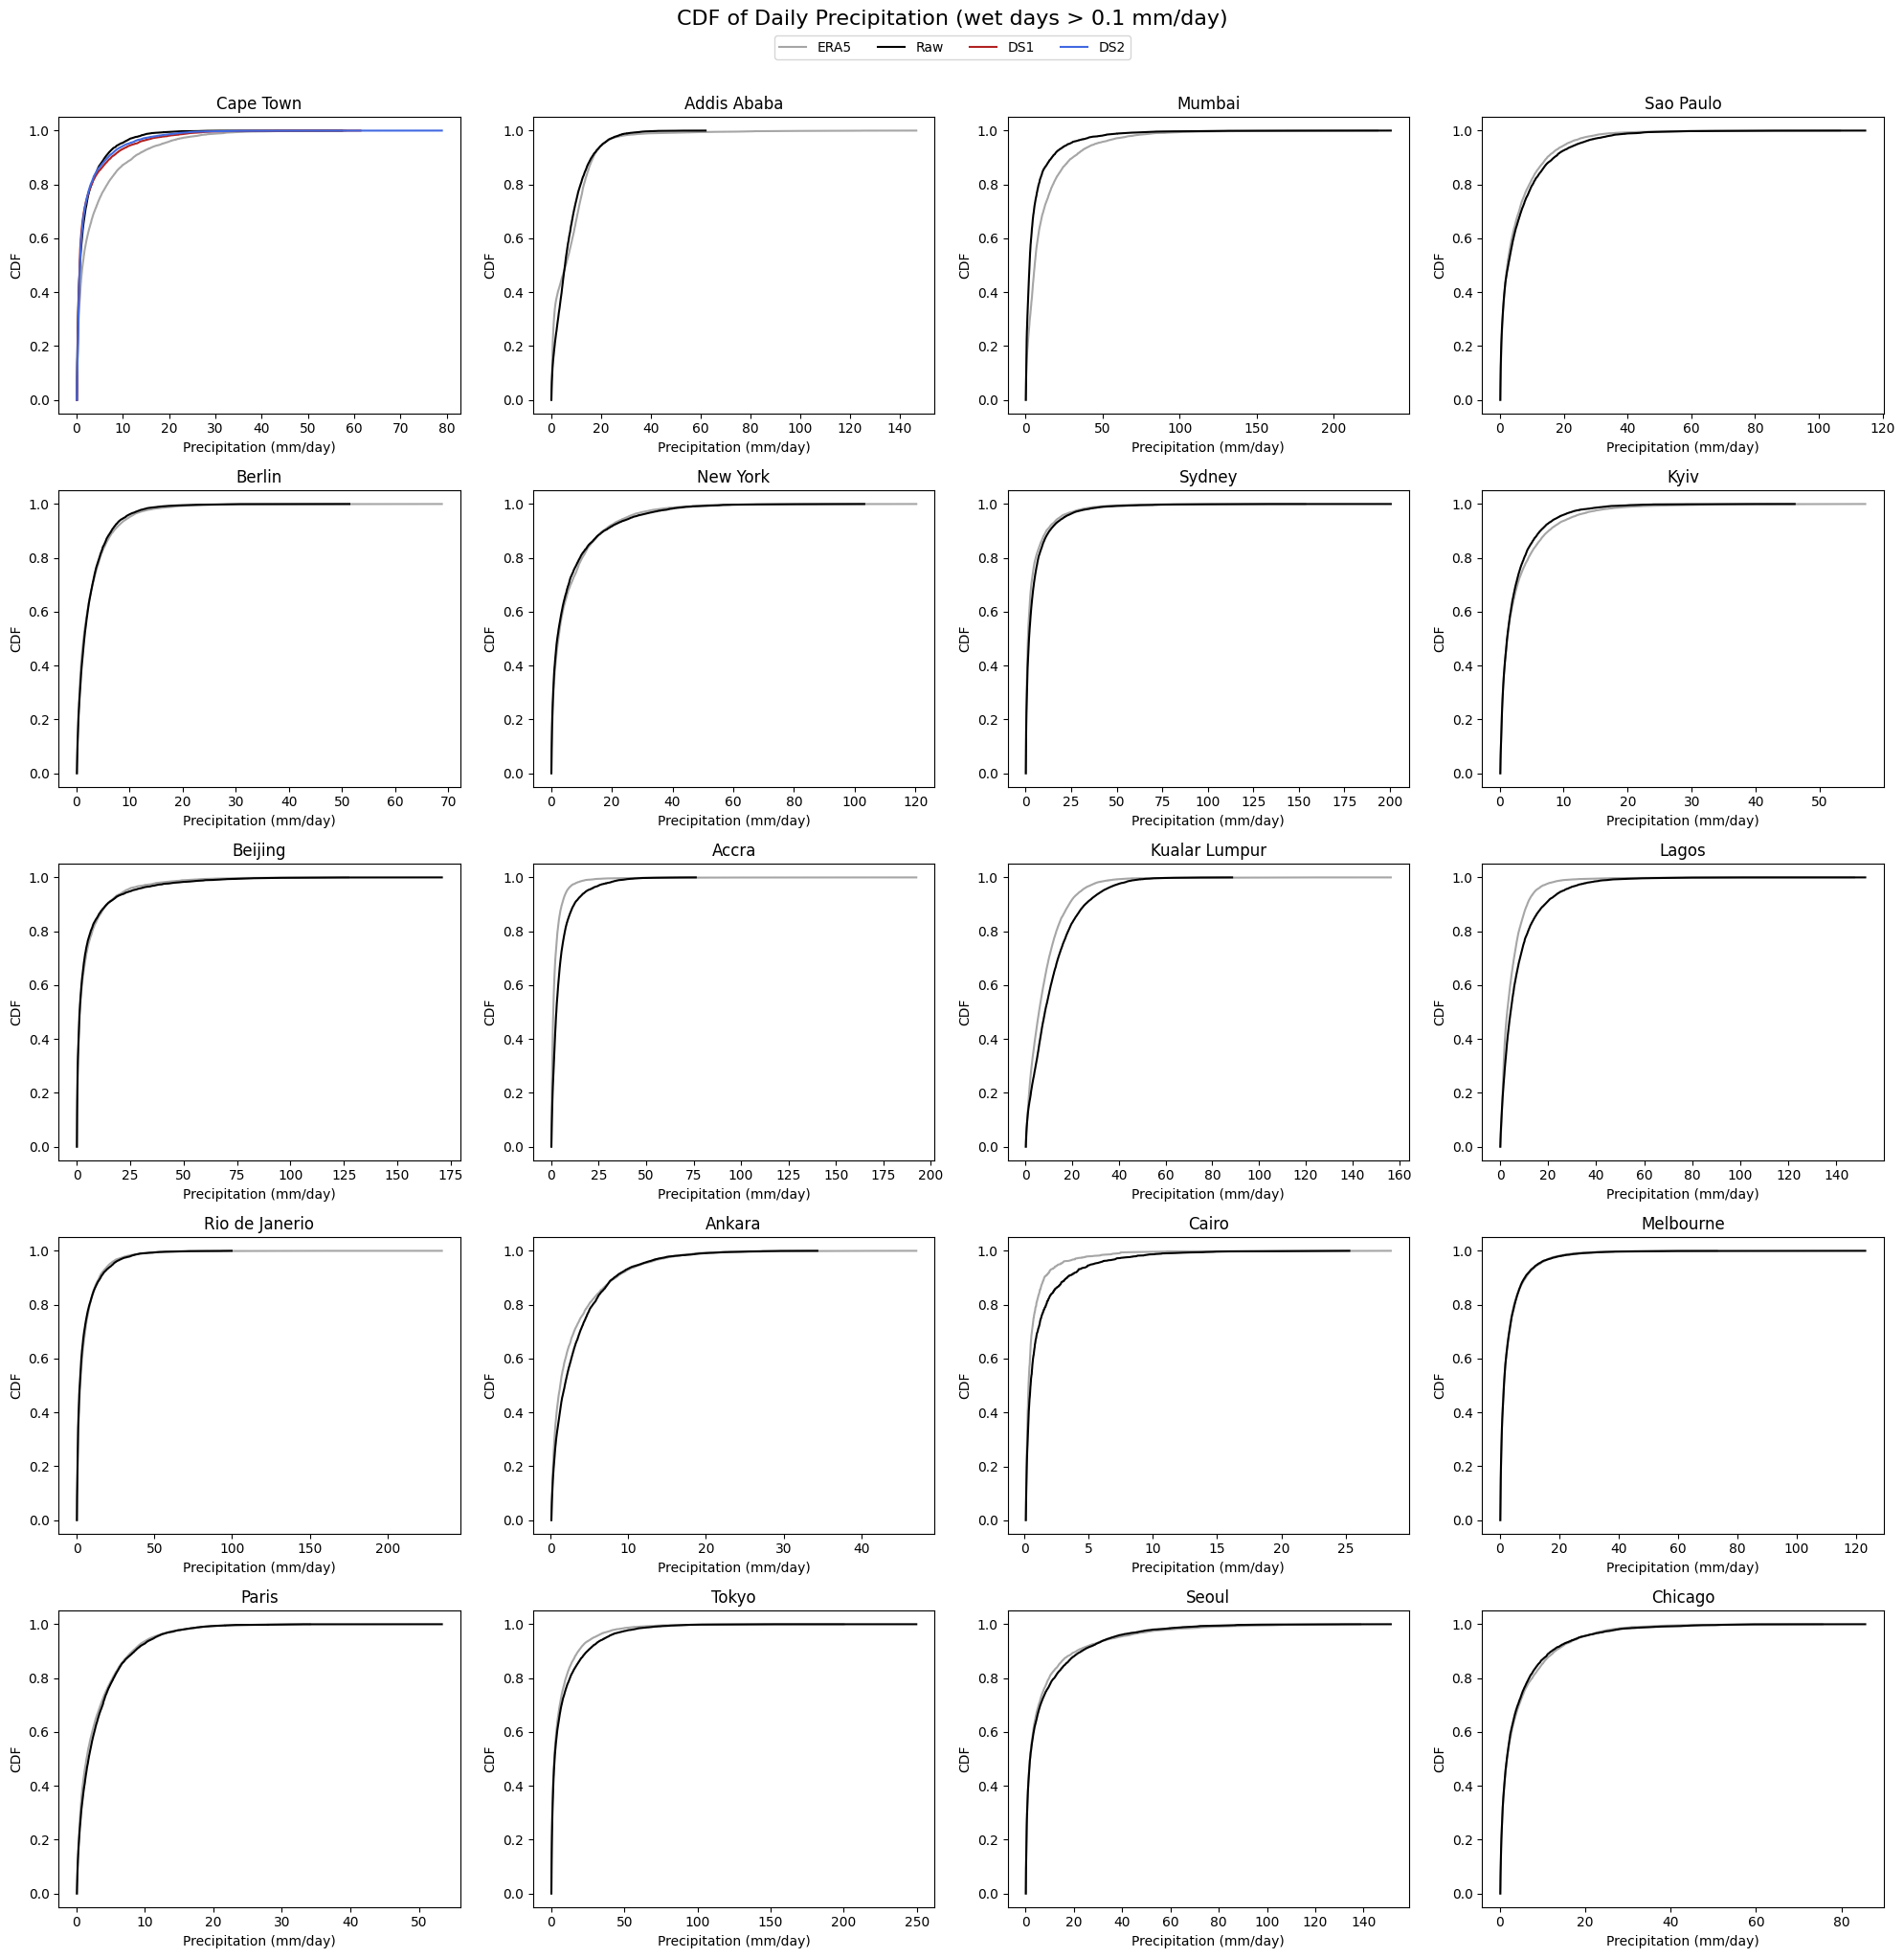

In [62]:
# CDF - Precipitation
variable = "pr"
threshold = 0.1

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]

    try:
        data = extract_location_data(
            era5_global,
            raw_global,
            ds1,
            ds2,
            lat,
            lon,
            variable,
            filter_precip=True,
            threshold=threshold,
        )

        has_data = False
        if data["era5"] is not None and len(data["era5"]) > 0:
            sorted_data = np.sort(data["era5"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="grey", alpha=0.7, label="ERA5")
            has_data = True
        if data["raw"] is not None and len(data["raw"]) > 0:
            sorted_data = np.sort(data["raw"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="k", label="Raw")
            has_data = True
        if data["ds1"] is not None and len(data["ds1"]) > 0:
            sorted_data = np.sort(data["ds1"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="firebrick", label="DS1")
            has_data = True
        if data["ds2"] is not None and len(data["ds2"]) > 0:
            sorted_data = np.sort(data["ds2"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="royalblue", label="DS2")
            has_data = True

        if not has_data:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(location)
        ax.set_xlabel("Precipitation (mm/day)")
        ax.set_ylabel("CDF")

    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {str(e)[:20]}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle(f"CDF of Daily Precipitation (wet days > {threshold} mm/day)", fontsize=16, y=1.02)
fig.legend(["ERA5", "Raw", "DS1", "DS2"], loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

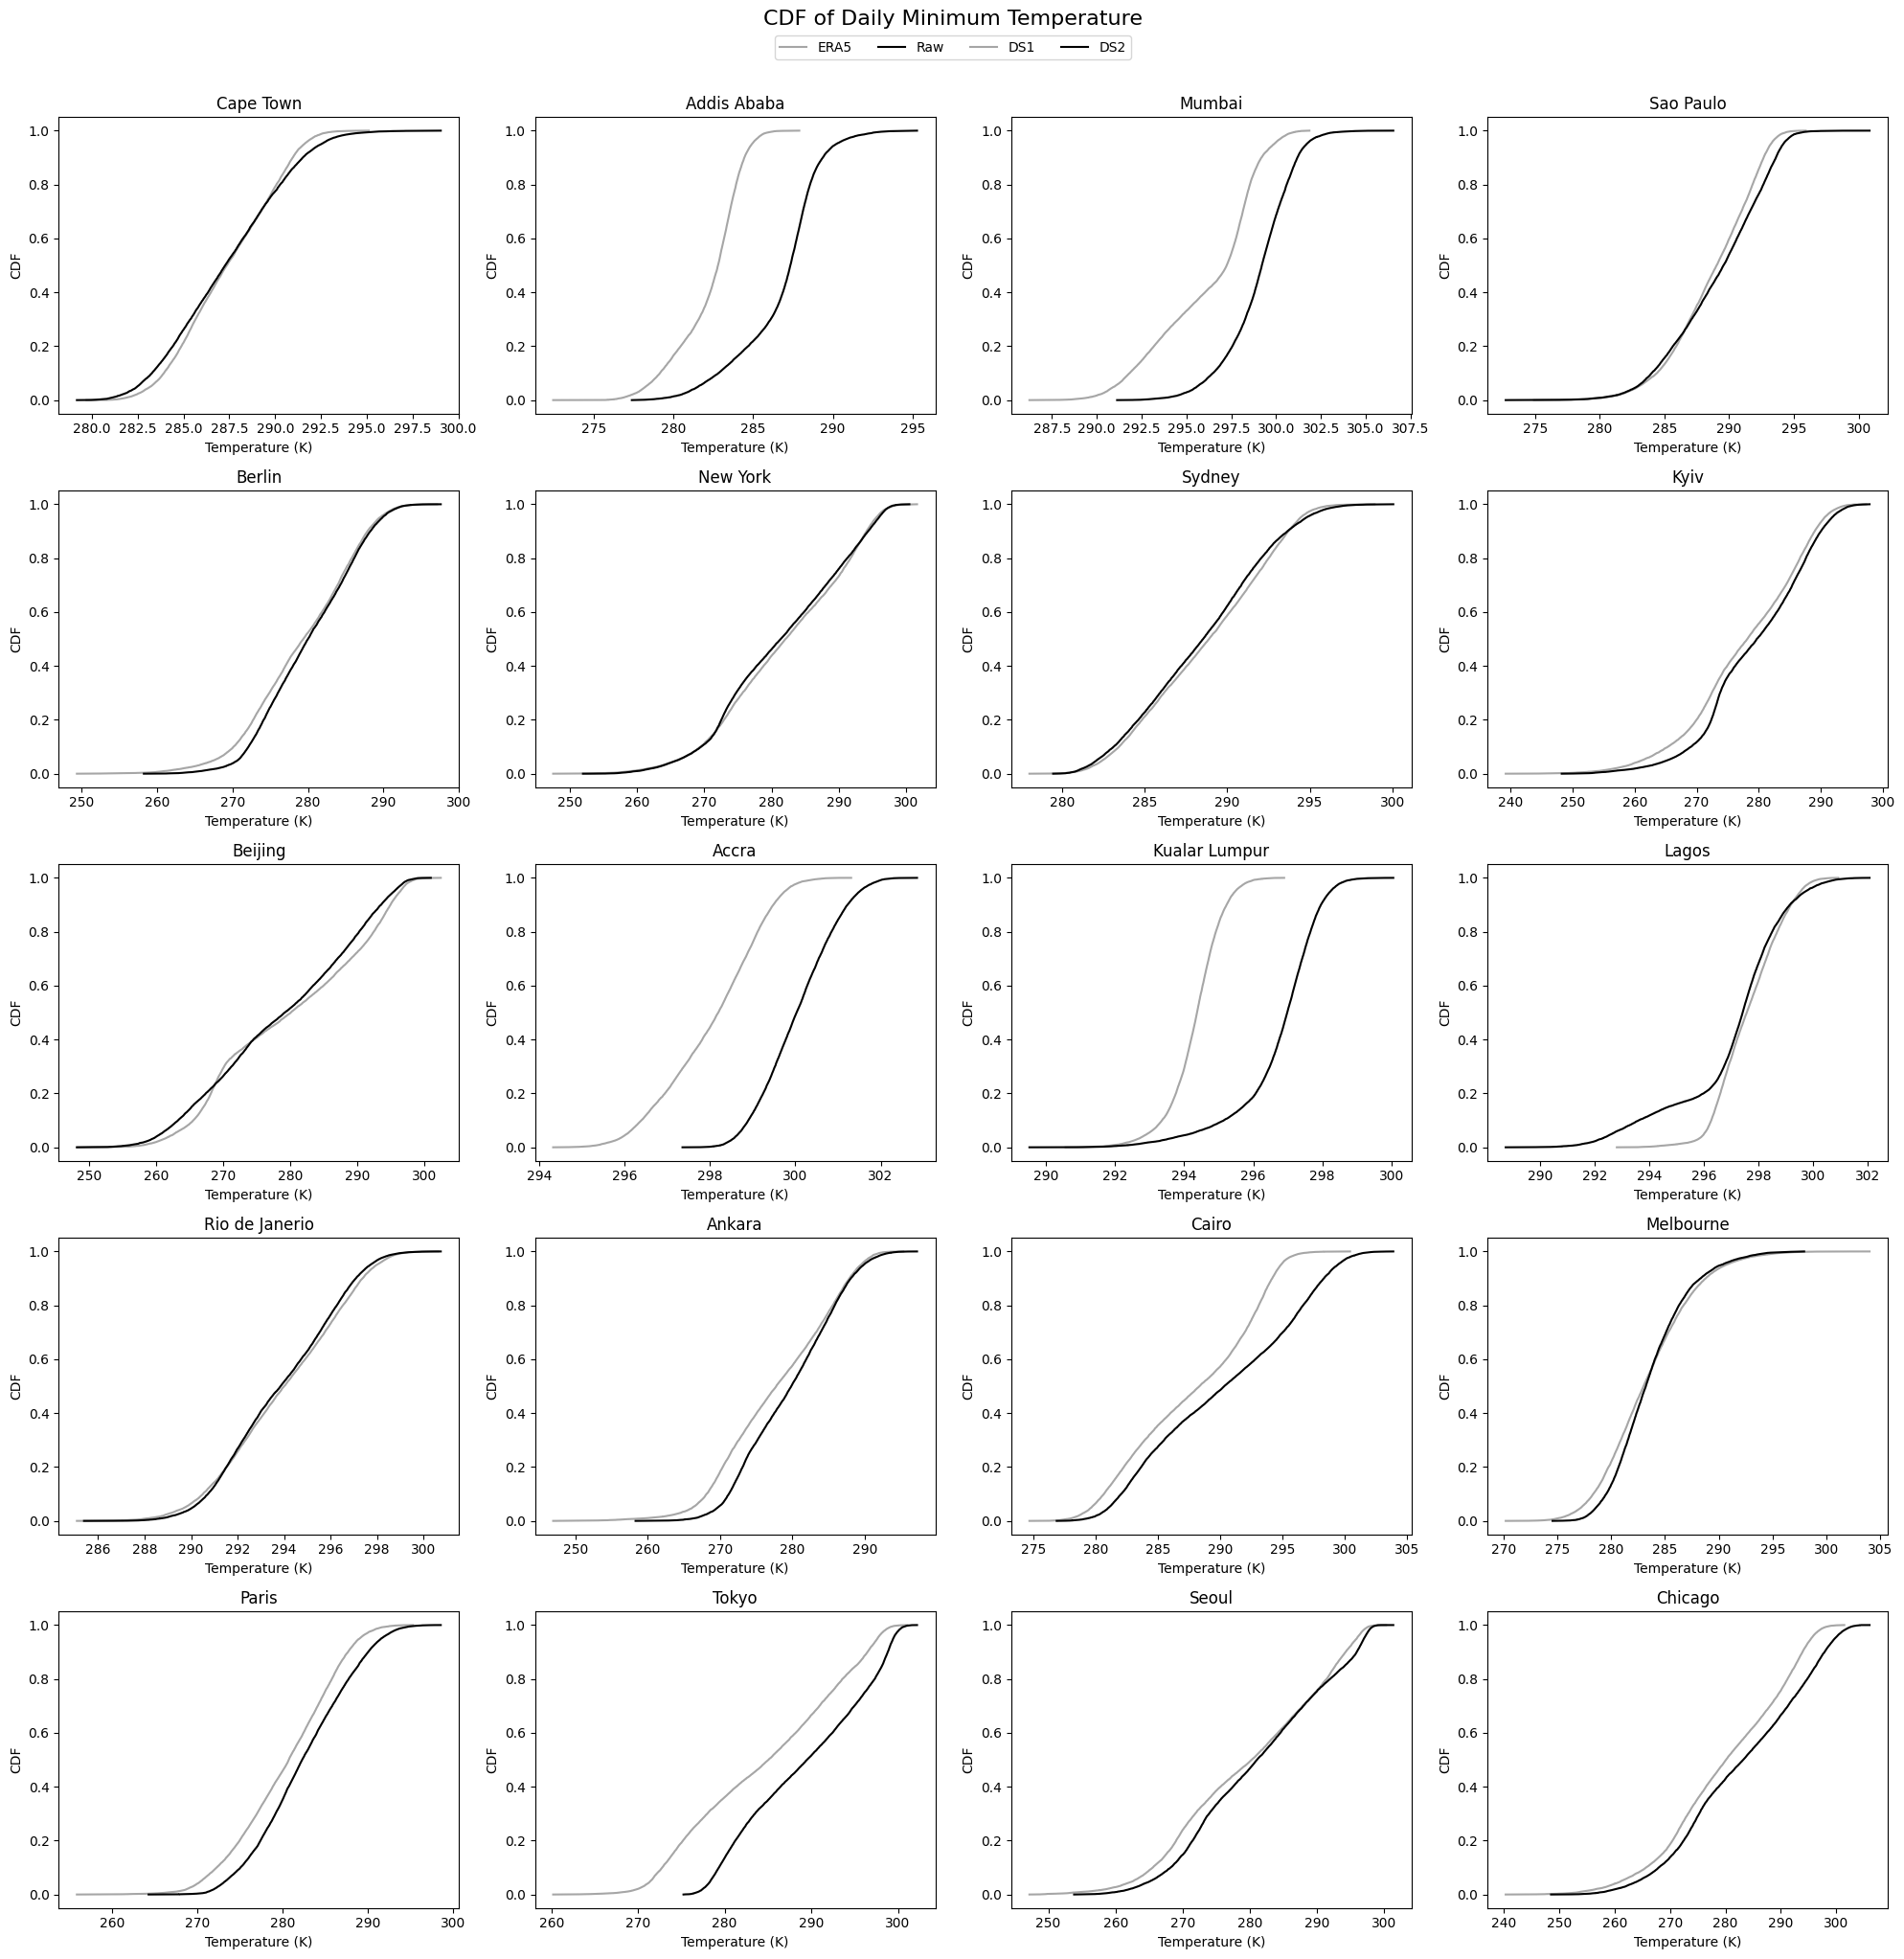

In [63]:
# CDF - Minimum Temperature (all locations)
variable = "tasmin"

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]

    try:
        data = extract_location_data(
            era5_global, raw_global, ds1_tas, ds2_tas, lat, lon, variable, filter_precip=False
        )

        has_data = False
        if data["era5"] is not None and len(data["era5"]) > 0:
            sorted_data = np.sort(data["era5"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="grey", alpha=0.7, label="ERA5")
            has_data = True
        if data["raw"] is not None and len(data["raw"]) > 0:
            sorted_data = np.sort(data["raw"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="k", label="Raw")
            has_data = True
        if data["ds1"] is not None and len(data["ds1"]) > 0:
            sorted_data = np.sort(data["ds1"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="firebrick", label="DS1")
            has_data = True
        if data["ds2"] is not None and len(data["ds2"]) > 0:
            sorted_data = np.sort(data["ds2"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="royalblue", label="DS2")
            has_data = True

        if not has_data:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(location)
        ax.set_xlabel("Temperature (K)")
        ax.set_ylabel("CDF")

    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {str(e)[:20]}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle("CDF of Daily Minimum Temperature", fontsize=16, y=1.02)
fig.legend(["ERA5", "Raw", "DS1", "DS2"], loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

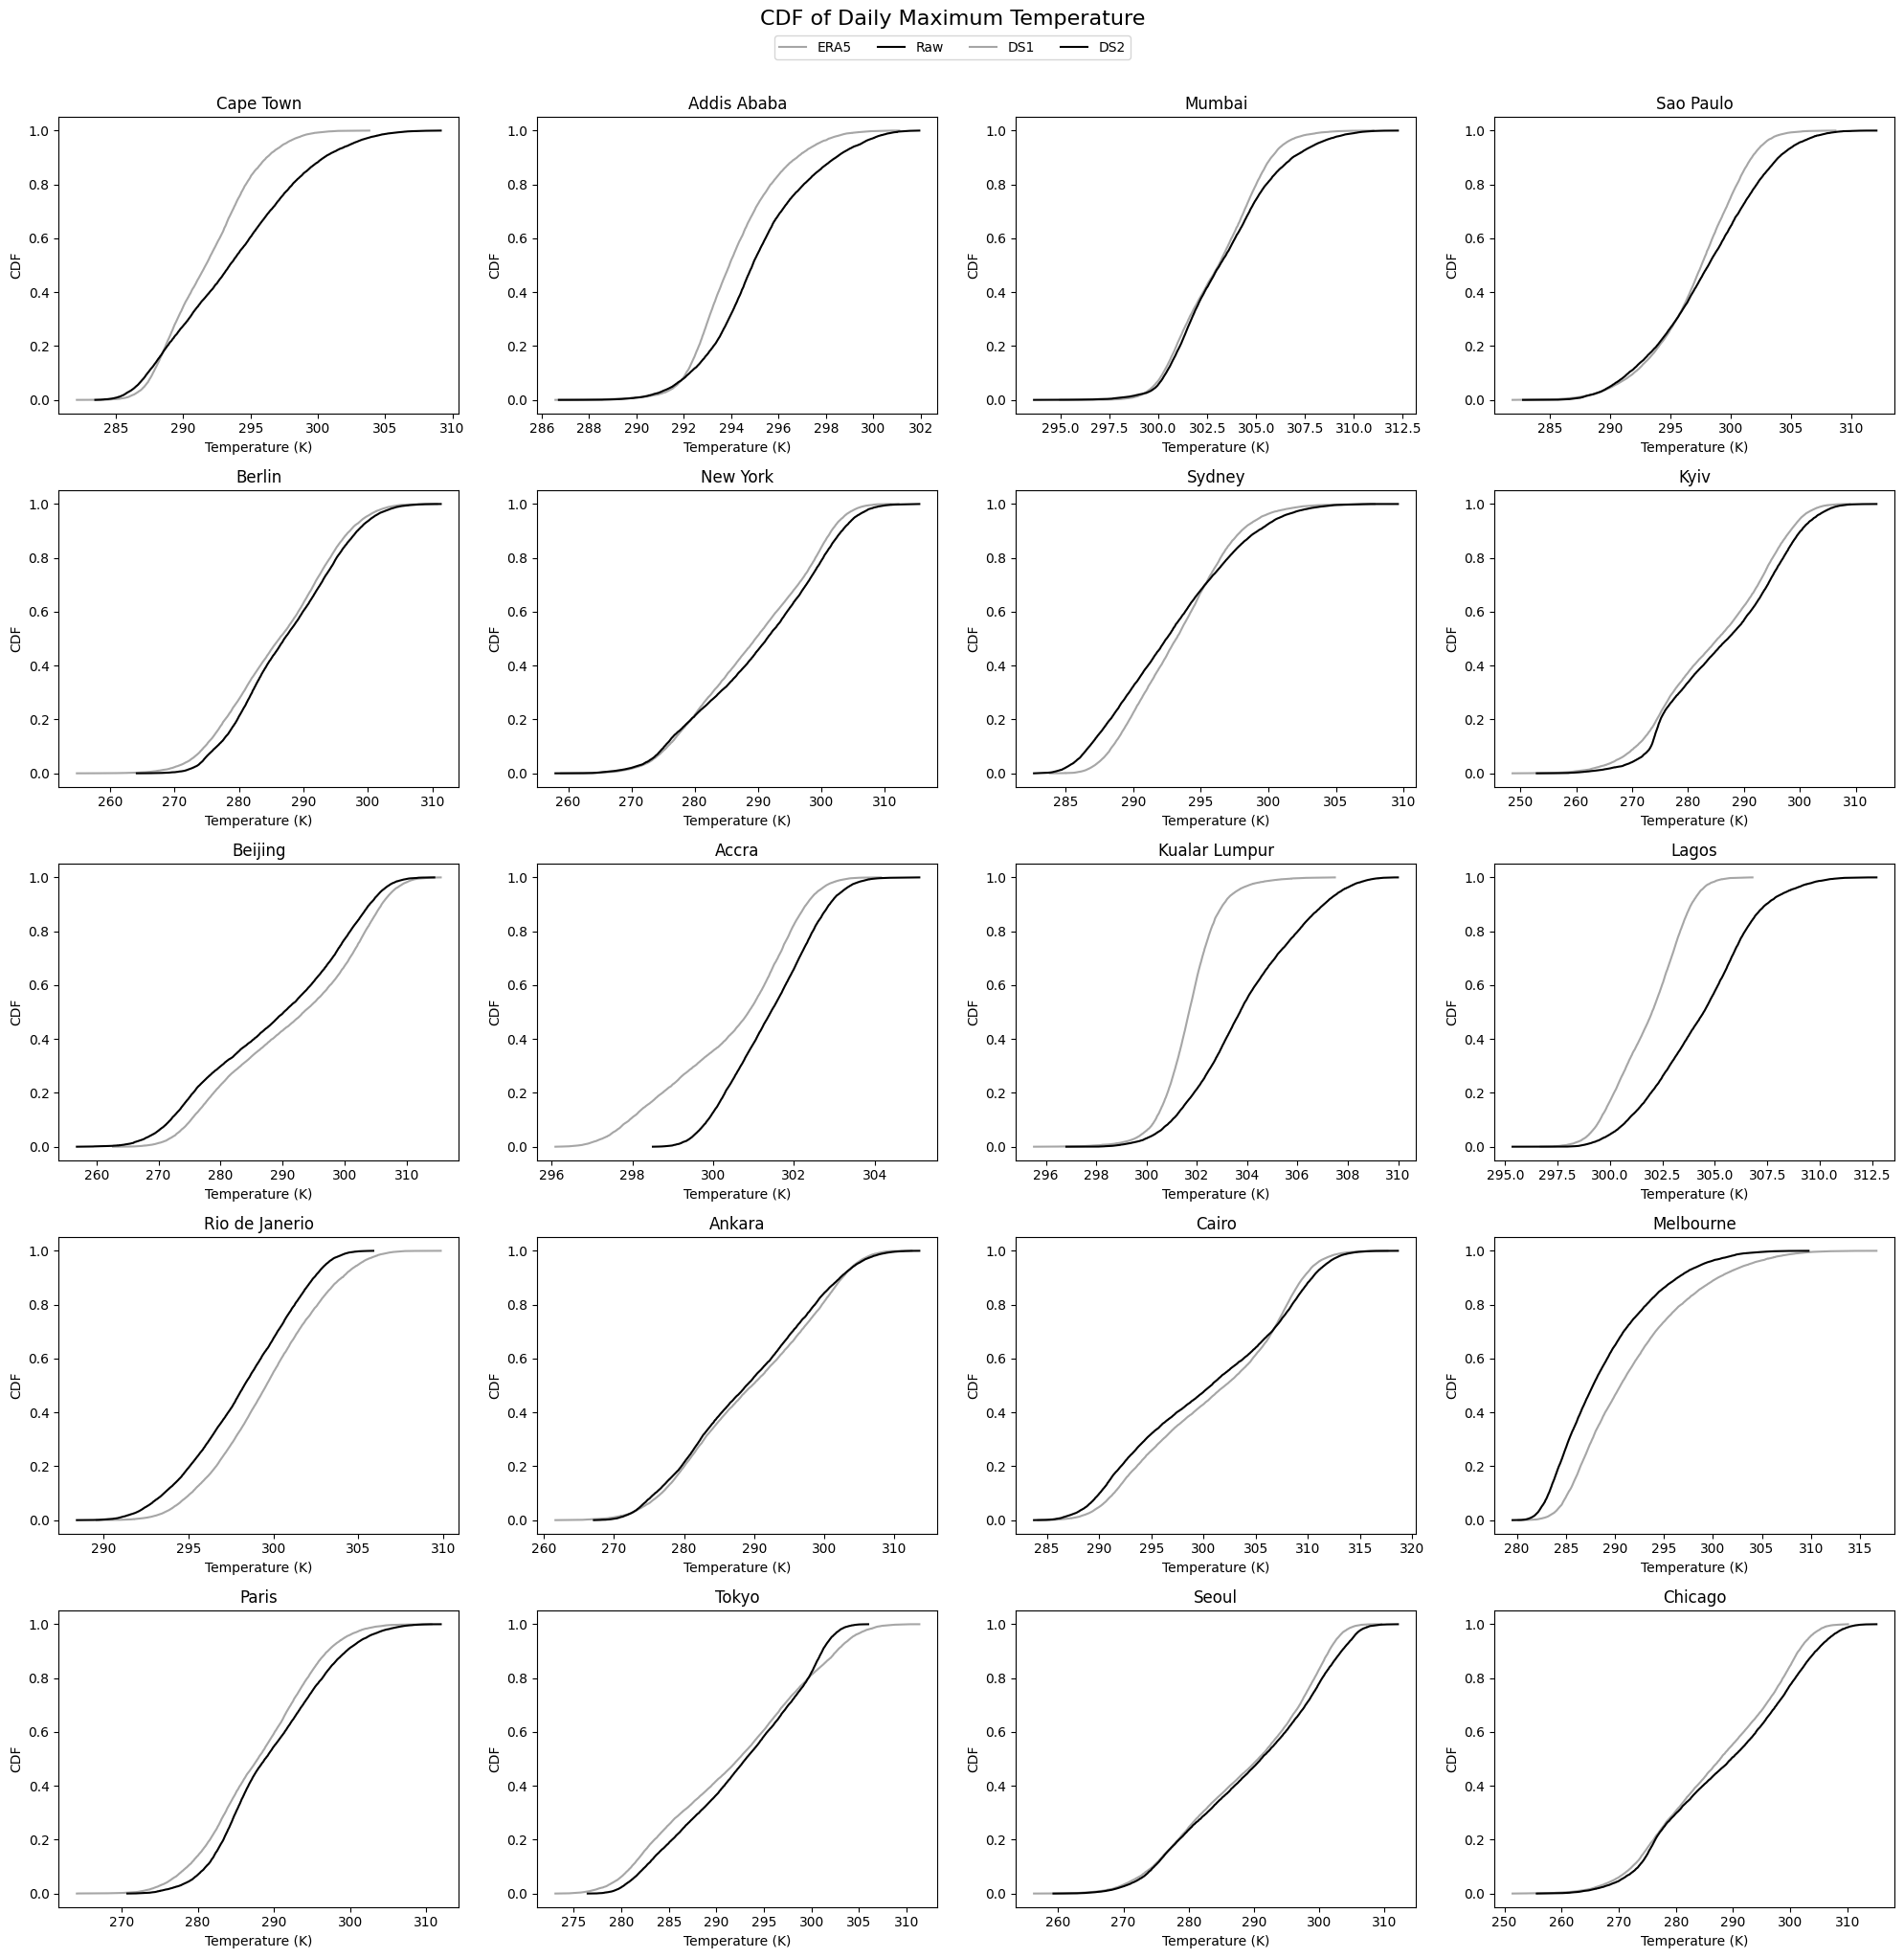

In [64]:
# CDF - Maximum Temperature (all locations)
variable = "tasmax"

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]

    try:
        data = extract_location_data(
            era5_global, raw_global, ds1_tas, ds2_tas, lat, lon, variable, filter_precip=False
        )

        has_data = False
        if data["era5"] is not None and len(data["era5"]) > 0:
            sorted_data = np.sort(data["era5"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="grey", alpha=0.7, label="ERA5")
            has_data = True
        if data["raw"] is not None and len(data["raw"]) > 0:
            sorted_data = np.sort(data["raw"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="k", label="Raw")
            has_data = True
        if data["ds1"] is not None and len(data["ds1"]) > 0:
            sorted_data = np.sort(data["ds1"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="firebrick", label="DS1")
            has_data = True
        if data["ds2"] is not None and len(data["ds2"]) > 0:
            sorted_data = np.sort(data["ds2"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="royalblue", label="DS2")
            has_data = True

        if not has_data:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(location)
        ax.set_xlabel("Temperature (K)")
        ax.set_ylabel("CDF")

    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {str(e)[:20]}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle("CDF of Daily Maximum Temperature", fontsize=16, y=1.02)
fig.legend(["ERA5", "Raw", "DS1", "DS2"], loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

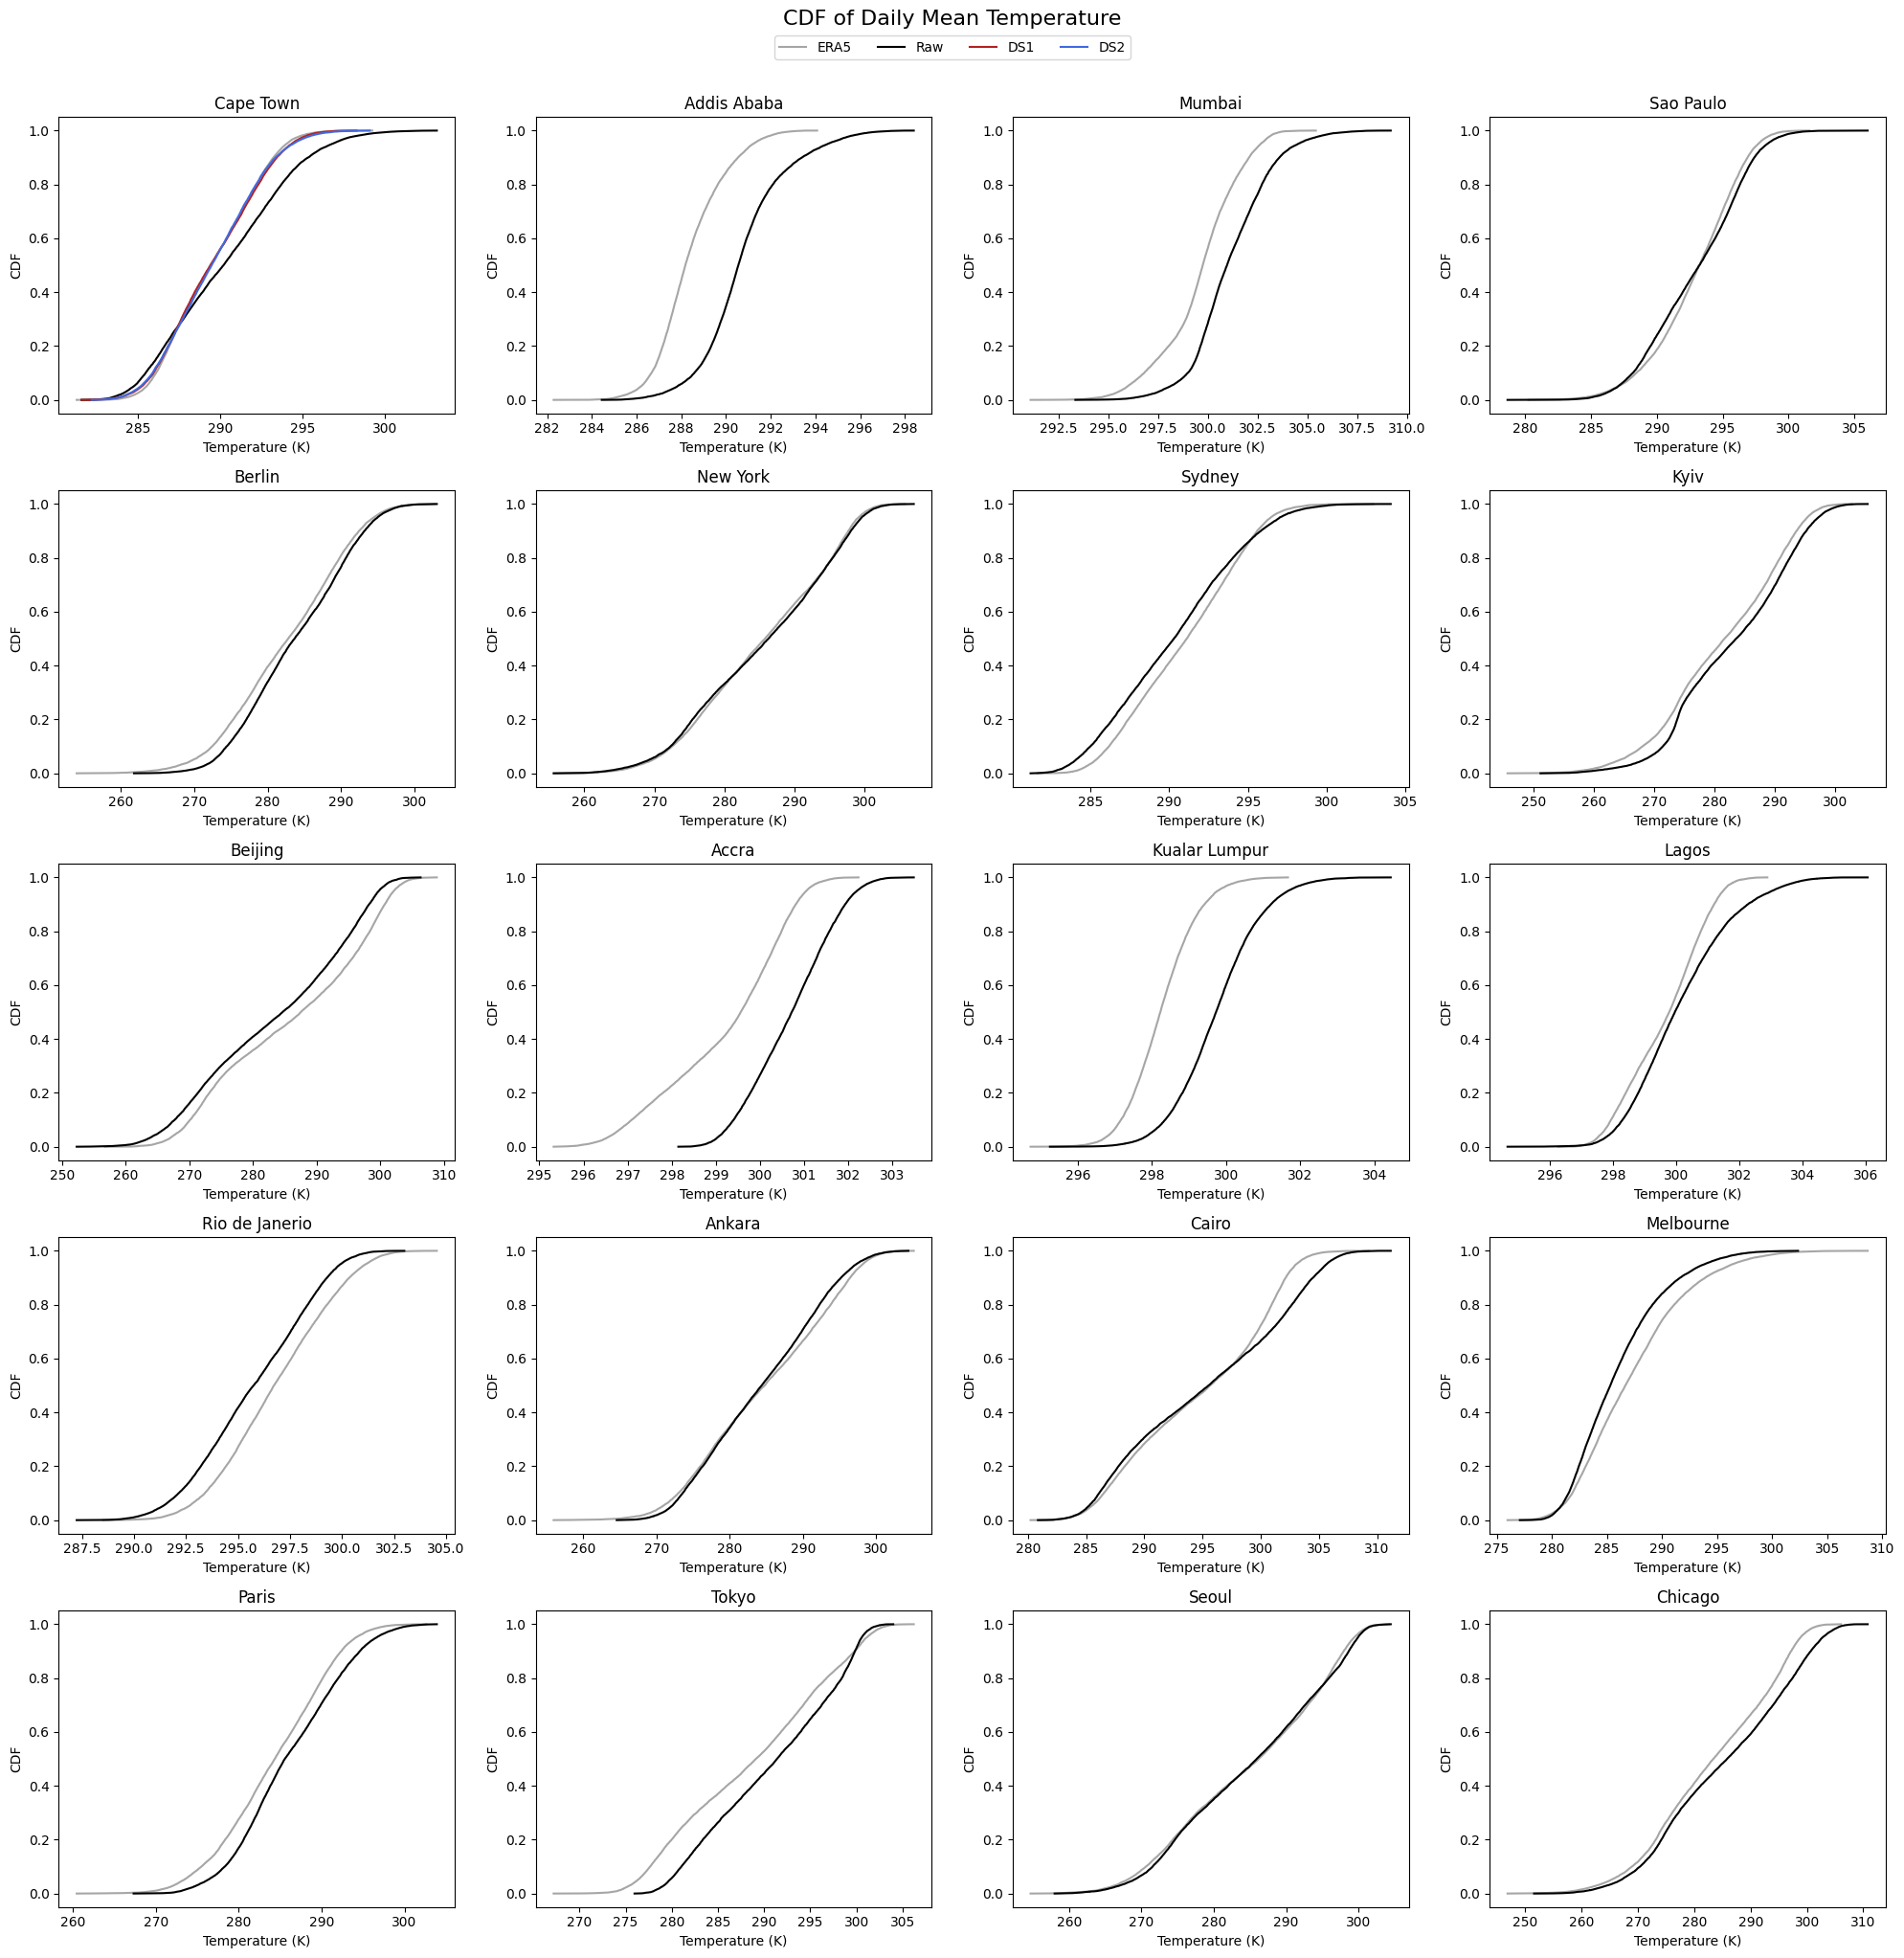

In [65]:
# CDF - Mean Temperature (all locations)
variable = "tas"

fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for i, (location, (lat, lon)) in enumerate(locations.items()):
    ax = axes[i]

    try:
        data = extract_location_data(
            era5_global, raw_global, ds1_tas, ds2_tas, lat, lon, variable, filter_precip=False
        )

        has_data = False
        if data["era5"] is not None and len(data["era5"]) > 0:
            sorted_data = np.sort(data["era5"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="grey", alpha=0.7, label="ERA5")
            has_data = True
        if data["raw"] is not None and len(data["raw"]) > 0:
            sorted_data = np.sort(data["raw"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="k", label="Raw")
            has_data = True
        if data["ds1"] is not None and len(data["ds1"]) > 0:
            sorted_data = np.sort(data["ds1"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="firebrick", label="DS1")
            has_data = True
        if data["ds2"] is not None and len(data["ds2"]) > 0:
            sorted_data = np.sort(data["ds2"].values)
            cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            ax.plot(sorted_data, cdf, color="royalblue", label="DS2")
            has_data = True

        if not has_data:
            ax.text(0.5, 0.5, "No data available", ha="center", va="center", transform=ax.transAxes)

        ax.set_title(location)
        ax.set_xlabel("Temperature (K)")
        ax.set_ylabel("CDF")

    except Exception as e:
        ax.text(0.5, 0.5, f"Error: {str(e)[:20]}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(location)

fig.suptitle("CDF of Daily Mean Temperature", fontsize=16, y=1.02)
fig.legend(["ERA5", "Raw", "DS1", "DS2"], loc="upper center", bbox_to_anchor=(0.5, 1.01), ncol=4)
plt.tight_layout()
plt.show()

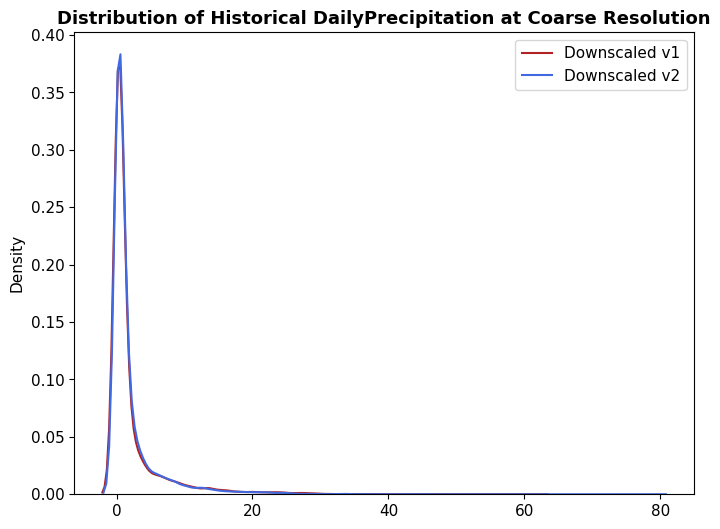

In [66]:
# temi TODO: make a function which create a 20-panel plot like the timeseries above, but each panel is the PDF below.
plot_pdf(
    era5_toplot,
    raw_toplot,
    ds1_toplot,
    "pr",
    ds2=ds2_toplot,
    title="Distribution of Historical DailyPrecipitation at Coarse Resolution",
)

In [67]:
# temi TODO: repeat the PDF figures (and update/extend the `plot_pdf` function as needed) for tasmax, tasmin, tas

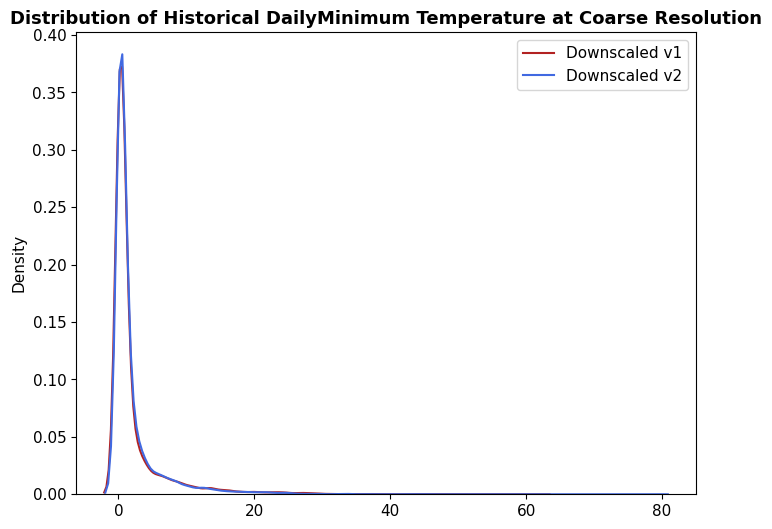

In [68]:
plot_pdf(
    era5_toplot,
    raw_toplot,
    ds1_toplot,
    "tasmin",
    ds2=ds2_toplot,
    title="Distribution of Historical DailyMinimum Temperature at Coarse Resolution",
)

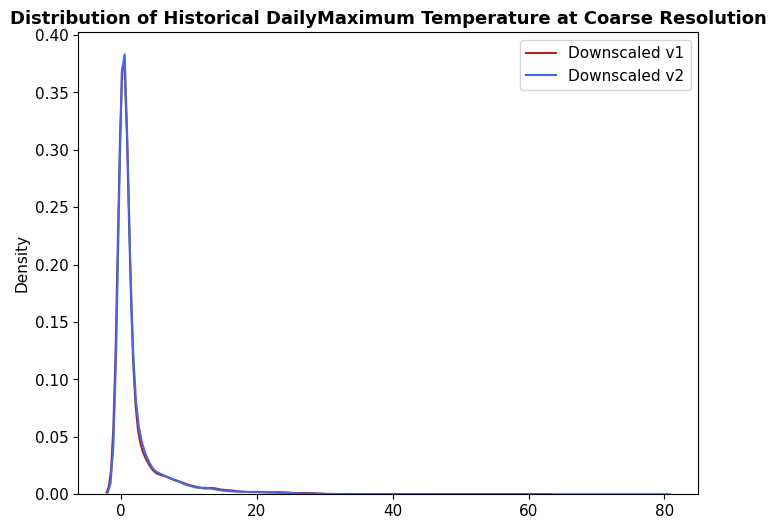

In [69]:
plot_pdf(
    era5_toplot,
    raw_toplot,
    ds1_toplot,
    "tasmax",
    ds2=ds2_toplot,
    title="Distribution of Historical DailyMaximum Temperature at Coarse Resolution",
)

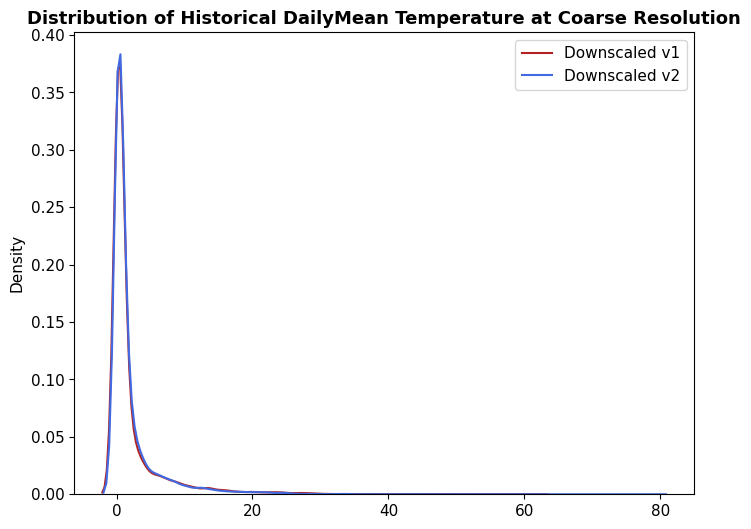

In [70]:
plot_pdf(
    era5_toplot,
    raw_toplot,
    ds1_toplot,
    "tas",
    ds2=ds2_toplot,
    title="Distribution of Historical DailyMean Temperature at Coarse Resolution",
)

A PDF shows how often different rainfall amounts occur, helping to see typical values and variability. A CDF shows the fraction of days with rainfall below a given amount, making it easier to understand how often heavy or extreme rainfall events occur. These plots show that raw GCM output tends to underestimate extreme rainfall events while overestimating the frequency of low rainfall days, a common bias known as the drizzle bias.

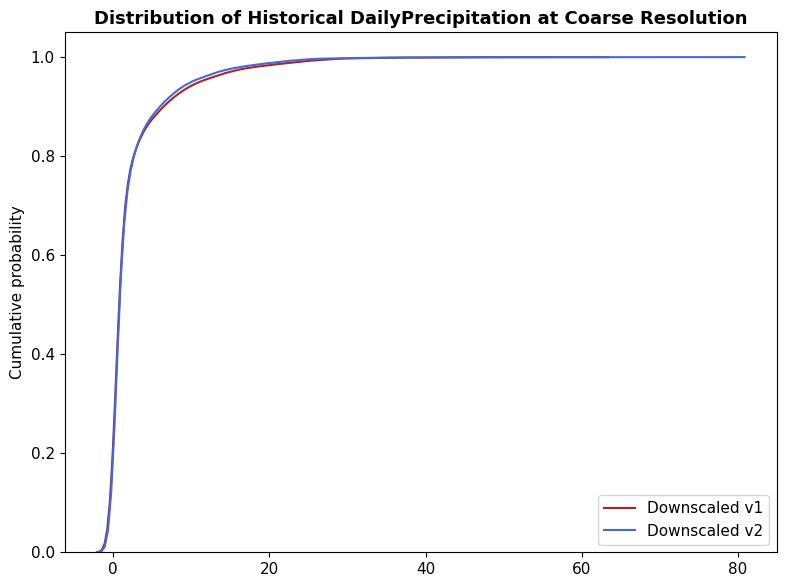

In [71]:
plot_cdf(
    era5_toplot,
    raw_toplot,
    ds1_toplot,
    "pr",
    ds2=ds2_toplot,
    title="Distribution of Historical DailyPrecipitation at Coarse Resolution",
)

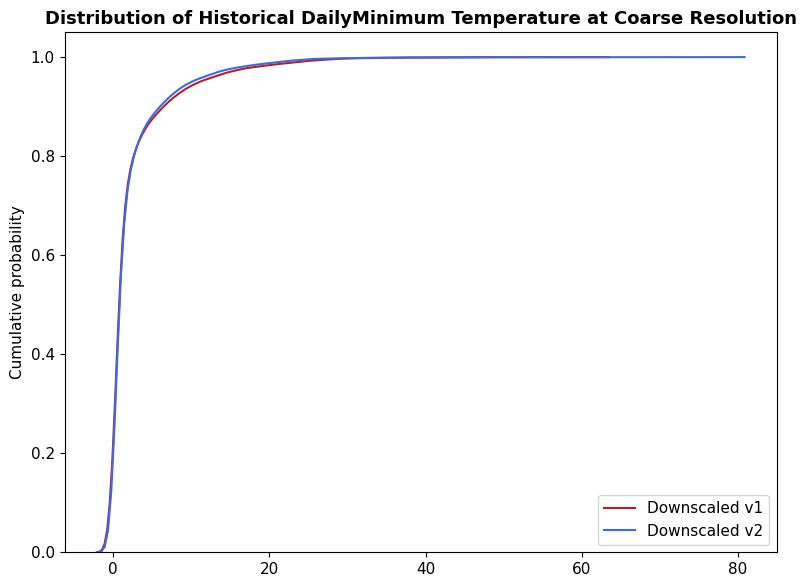

In [72]:
plot_cdf(
    era5_toplot,
    raw_toplot,
    ds1_toplot,
    "tasmin",
    ds2=ds2_toplot,
    title="Distribution of Historical DailyMinimum Temperature at Coarse Resolution",
)

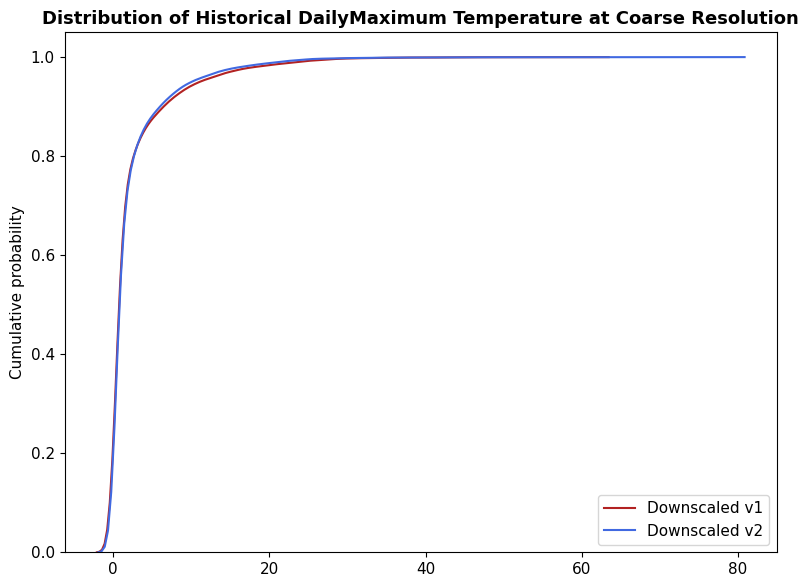

In [73]:
plot_cdf(
    era5_toplot,
    raw_toplot,
    ds1_toplot,
    "tasmax",
    ds2=ds2_toplot,
    title="Distribution of Historical DailyMaximum Temperature at Coarse Resolution",
)

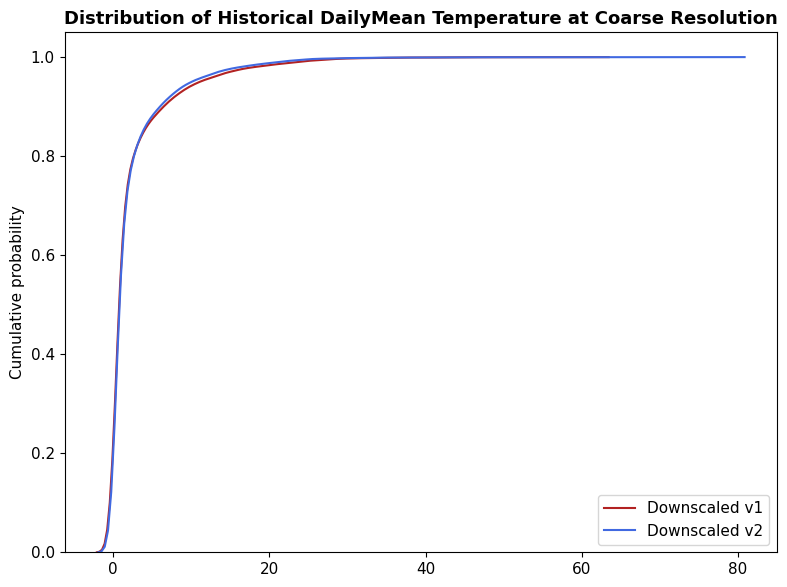

In [74]:
plot_cdf(
    era5_toplot,
    raw_toplot,
    ds1_toplot,
    "tas",
    ds2=ds2_toplot,
    title="Distribution of Historical DailyMean Temperature at Coarse Resolution",
)